## **Credit Risk Assessment**
#### Improving Business with Credit Risk Model
---

### ***1. Factors that are used for Credit Assessment***

In order to assess the credit risk associated with any financial proposal, the project finance division of the firm first assesses a variety of risks relating to the borrower and the relevant industry.

The borrower credit risk is evaluated by considering:

- The financial position of the borrower, by analyzing the quality of its financial statements, its past financial performance, its financial flexibility in terms of the ability to raise capital, and its capital adequacy

- The borrower’s relative market position and operating efficiency

- The quality of management, by analyzing its track record, payment record, and financial conservatism

Industry-specific credit risk is evaluated by considering:

- Certain industry characteristics, such as the importance of the industry to the economic growth of the economy and government policies relating to the industry

- The competitiveness of the industry

- Certain industry financials, including return on capital employed, operating margins, and earnings stability
---

### ***2. Defining the business metrics***
When analyzing the performance metrics for classification machine learning algorithms, we often stumble on the **Confusion Matrix**.


We need to define which case is the **best for the business**:

- A) Reduce False Positives (FP) rather than False Negatives (FN).
- B) Reduce False Negatives (FN) rather than False Positives (FP).

In this project, I assumed that the best case for the business was **option (B)**, that is, **a default on a loan is worse that not giving a loan to a person**.

---

### ***3. Loading data***

In [4]:
import pandas as pd
df = pd.read_csv("data/raw_cr_loan2.csv")
df.shape
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


### ***Importing Other Essential Libraries***

In [3]:
# data manipulation
import numpy as np

# EDA
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
from scipy.stats import chi2_contingency

# preprocessing
from sklearn.preprocessing import MinMaxScaler

# modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

# evaluation
from sklearn.metrics import (
    classification_report, precision_recall_fscore_support, f1_score,
    roc_curve, roc_auc_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, brier_score_loss
)

# calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [9]:
# Descriptive Statistics
# creating a ds for numerical attributes
num_attributes = df.select_dtypes(include=['int64', 'float64'])

# creates a ds for categorical attributes
cat_attributes = df.select_dtypes(exclude=['int64', 'float64'])

num_attributes.sample(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
7675,22,54000,3.0,9000,7.51,0,0.17,3
28220,31,68000,15.0,13600,7.88,0,0.20,5


In [10]:
cat_attributes.sample(2)

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
27150,MORTGAGE,HOMEIMPROVEMENT,A,N
14983,MORTGAGE,VENTURE,C,N


In [13]:
# central tendency: mean, median
mean = pd.DataFrame(num_attributes.apply(np.mean)).T
median = pd.DataFrame(num_attributes.apply(np.median)).T

# distribution: std, min, max, range, skew, kurtosis
std = pd.DataFrame(num_attributes.apply(np.std)).T
min_value = pd.DataFrame(num_attributes.apply(min)).T
max_value = pd.DataFrame(num_attributes.apply(max)).T
range_value = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T
skewness = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
kurtosis = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T

# concatenates
stats_summary = pd.concat([min_value, max_value, range_value, mean, median, std, skewness, kurtosis]).T.reset_index()
stats_summary.columns = ['attributes','min','max','range','mean','median','std','skewness','kurtosis']

stats_summary

,attributes,min,max,range,mean,median,std,skewness,kurtosis
0,person_age,20.00,144.00,124.00,27.734600,26.00,6.347981,2.581393,18.560825
1,person_income,4000.00,6000000.00,5996000.00,66074.848470,55000.00,61982.167945,32.865349,2693.272776
2,person_emp_length,0.00,123.00,123.00,4.789686,NaN,4.142565,2.614455,43.722338
3,loan_amnt,500.00,35000.00,34500.00,9589.371106,8000.00,6321.989624,1.192477,1.423565
4,loan_int_rate,5.42,23.22,17.80,11.011695,NaN,3.240404,0.208550,-0.671609
5,loan_status,0.00,1.00,1.00,0.218164,0.00,0.412999,1.364888,-0.137088
6,loan_percent_income,0.00,0.83,0.83,0.170203,0.15,0.106780,1.064669,1.223687
7,cb_person_cred_hist_length,2.00,30.00,28.00,5.804211,4.00,4.054939,1.661790,3.716194


As observed, we can notice the presence of outliers in `person_age` (`max = 144`) and `person_emp_length` (`max = 123`).

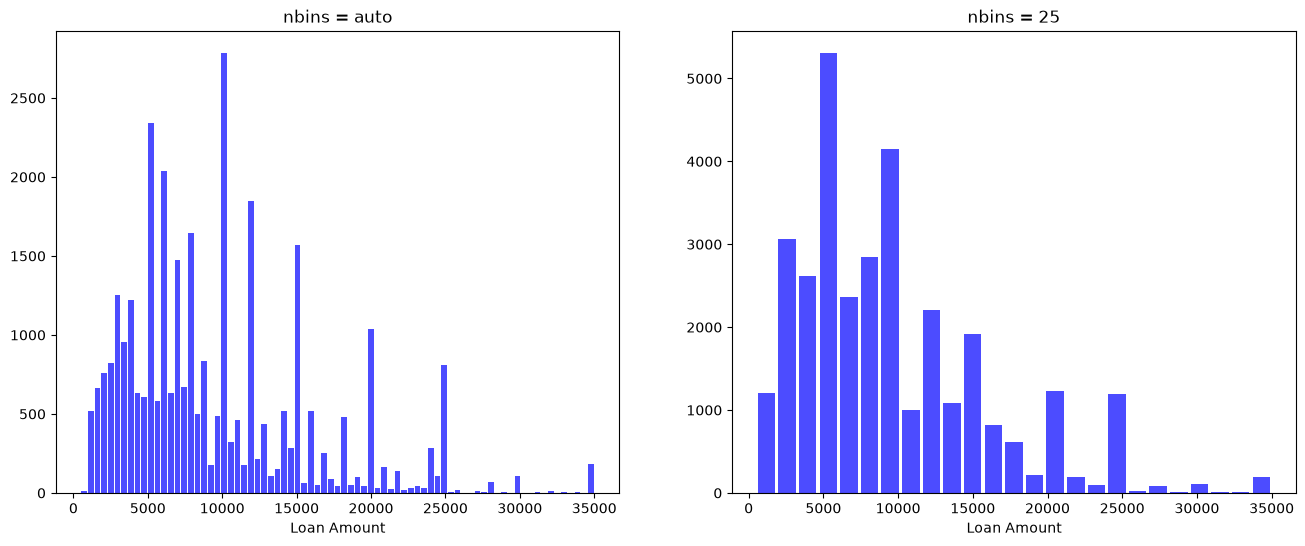

In [14]:
# Plotting the distribution of loan amounts with a histogram
plt.figure(figsize=(16, 6))

plt.subplot(1,2,1)
n, bins, patches = plt.hist(x=df['loan_amnt'], bins='auto', color='blue', alpha=0.7, rwidth=0.85)
plt.title("nbins = auto")
plt.xlabel("Loan Amount")

plt.subplot(1,2,2)
n, bins, patches = plt.hist(x=df['loan_amnt'], bins=25, color='blue', alpha=0.7, rwidth=0.85)
plt.title("nbins = 25")
plt.xlabel("Loan Amount")

plt.show()

### Using Crosstabs 
where 1 is Loan default 

In [17]:
pd.crosstab(df['loan_intent'], df['loan_status'], margins=True)

loan_status,0,1,All
loan_intent,,,
DEBTCONSOLIDATION,3722,1490,5212
EDUCATION,5342,1111,6453
HOMEIMPROVEMENT,2664,941,3605
MEDICAL,4450,1621,6071
PERSONAL,4423,1098,5521
VENTURE,4872,847,5719
All,25473,7108,32581


As observed: 
- `VENTURE` has the least number of defaults while `MEDICAL` has the most.
- `EDUCATION` and `MEDICAL` are the greatest loan intents while `HOMEIMPROVEMENT` is the least.
- `MEDICAL` and `DEBTCONSOLIDATION` are the intents where there are more defaults.

In [18]:
# cross table of home ownership, loan status, and grade
pd.crosstab(df['person_home_ownership'], [df['loan_status'], df['loan_grade']], 
            margins=True)

loan_status               0                                   1              \
loan_grade                A     B     C     D    E   F  G     A     B     C   
person_home_ownership                                                         
MORTGAGE               5219  3729  1934   658  178  36  0   239   324   321   
OTHER                    23    29    11     9    2   0  0     3     5     6   
OWN                     860   770   464   264   26   7  0    66    34    31   
RENT                   3602  4222  2710   554  137  28  1   765  1338   981   
All                    9704  8750  5119  1485  343  71  1  1073  1701  1339   

loan_status                                  All  
loan_grade                D    E    F   G         
person_home_ownership                             
MORTGAGE                553  161   61  31  13444  
OTHER                    11    6    2   0    107  
OWN                      18   31    8   5   2584  
RENT                   1559  423   99  27  16446  
All                    2141  621  170  63  32581

In [19]:
# cross table of home ownership, loan status, and average percent income
pd.crosstab(df['person_home_ownership'], df['loan_status'],
              values=df['loan_percent_income'], aggfunc='mean')

loan_status,0,1
person_home_ownership,,
MORTGAGE,0.146504,0.184882
OTHER,0.143784,0.300000
OWN,0.180013,0.297358
RENT,0.144611,0.264859


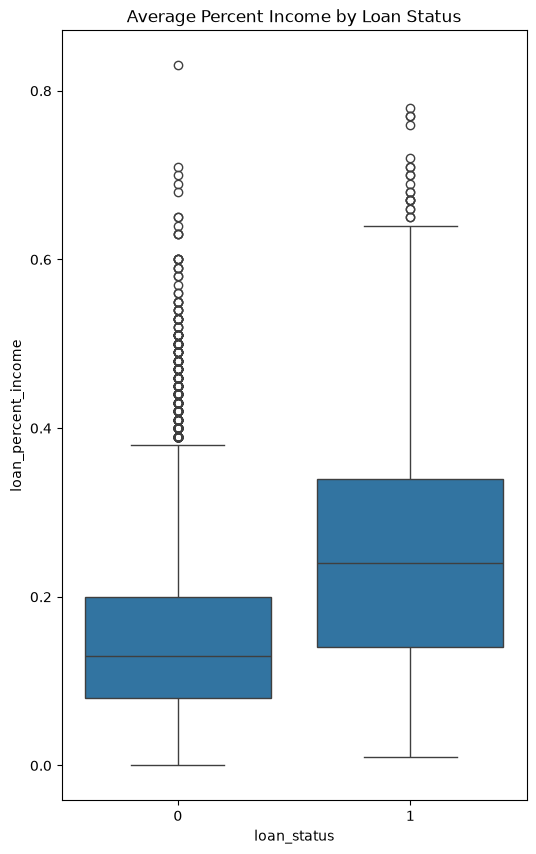

In [ ]:
# a box plot of percentage income by loan status
plt.figure(figsize=(6, 10))

plt.title('Average Percent Income by Loan Status')

sns.boxplot(x='loan_status' , y='loan_percent_income', data=df)

plt.show()

 It looks like the **average percentage of income for defaults is higher**. This could indicate those recipients have a debt-to-income ratio that's already too high.

### ***Checking Outliers***

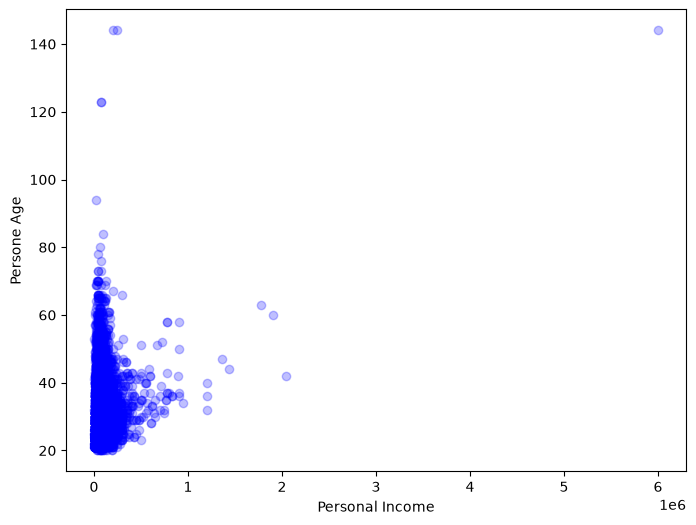

In [26]:
# Scatter Plot 
#  a scatter plot of income against age
plt.figure(figsize=(8, 6))

plt.scatter(df['person_income'], df['person_age'], color='blue', alpha=0.25)
plt.xlabel('Personal Income')
plt.ylabel('Persone Age')

plt.show()

So, as expected there's a positive corelation btwn age and income as the person gets old which means these older recipients are further along in their career and therefore earn higher salaries. There also appears to have outliers in the data.

In [30]:
# 1st of all removing the outliers in emp length as emploment length canot be more than 60
indices = df[df['person_emp_length'] > 60].index

len(indices)

2

In [31]:
# dropping the records from the data based on the indices and creating a new df
df_new = df.drop(indices)

#### ***Visualizing Credit Outliers***

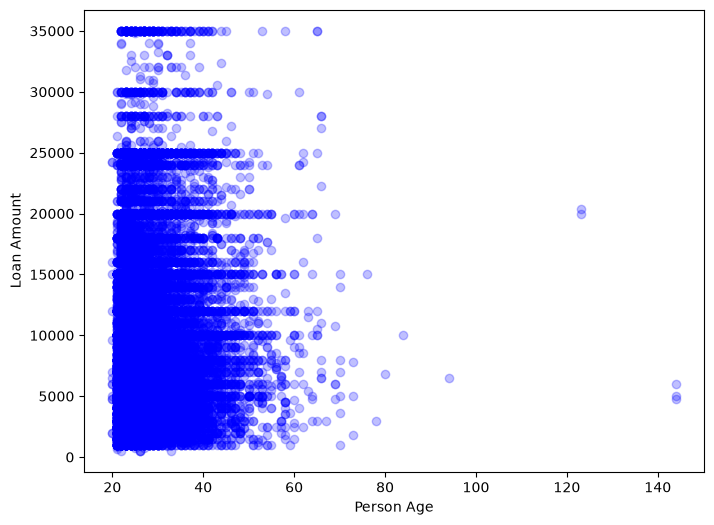

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(df_new['person_age'], df_new['loan_amnt'], color='blue', alpha=0.25)
plt.xlabel("Person Age")
plt.ylabel("Loan Amount")
plt.show()

In [33]:
# dropping the records with person age more than 100
df_new = df_new.drop(df_new[df_new['person_age'] > 100].index)

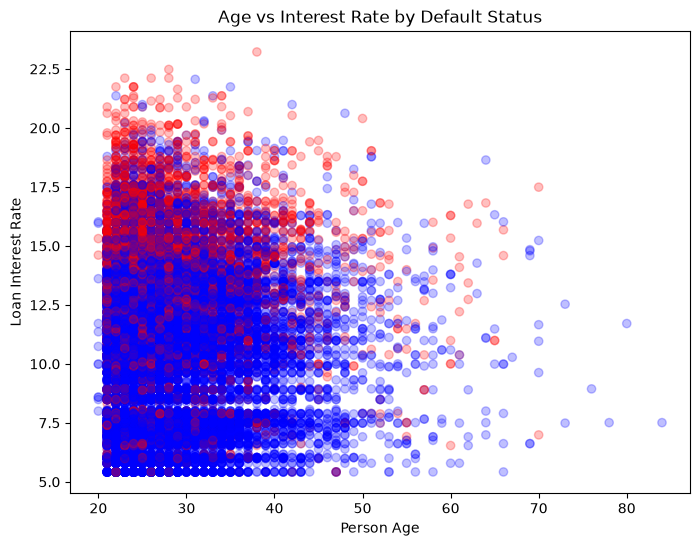

In [ ]:
# creating a scatter plot of age and interest rate
import matplotlib
import matplotlib.pyplot as plt

colors = ["blue", "red"]
plt.figure(figsize=(8, 6))
plt.scatter(df_new['person_age'], df_new['loan_int_rate'],
            c=df_new['loan_status'],
            cmap=matplotlib.colors.ListedColormap(colors),
            alpha=0.25)
plt.xlabel("Person Age")
plt.ylabel("Loan Interest Rate")
plt.title("Age vs Interest Rate by Default Status")
plt.show()

### ***Checking Misiing data***

In [40]:
df=df_new.copy()

df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3115
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [42]:
df[df['person_emp_length'].isnull()].head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
105,22,12600,MORTGAGE,NaN,PERSONAL,A,2000,5.42,1,0.16,N,4
222,24,185000,MORTGAGE,NaN,EDUCATION,B,35000,12.42,0,0.19,N,2
379,24,16800,MORTGAGE,NaN,DEBTCONSOLIDATION,A,3900,NaN,1,0.23,N,3
407,25,52000,RENT,NaN,PERSONAL,B,24000,10.74,1,0.46,N,2
408,22,17352,MORTGAGE,NaN,EDUCATION,C,2250,15.27,0,0.13,Y,3


In [50]:
# Replacing Null values with median value for all employment lengths
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

In [51]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3115
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

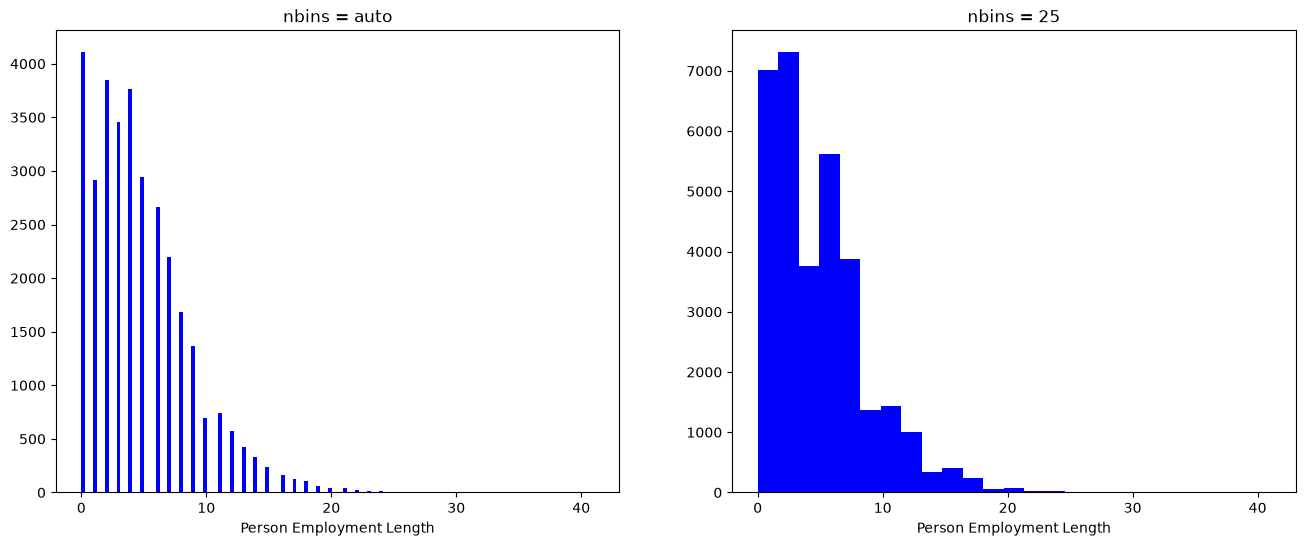

In [53]:
# creating a histogram of employment length
plt.figure(figsize=(16, 6))

plt.subplot(1,2,1)
n, bins, patches = plt.hist(df['person_emp_length'], bins='auto', color='blue')
plt.xlabel("Person Employment Length")
plt.title("nbins = auto")

plt.subplot(1,2,2)
n, bins, patches = plt.hist(df['person_emp_length'], bins=25, color='blue')
plt.xlabel("Person Employment Length")
plt.title("nbins = 25")

plt.show()

### ***Removing Missing data***

We replaced missing data in `person_emp_length`, but in the previous exercise we saw that `loan_int_rate` has missing data as well.

Similar to having missing data within `loan_status`, having missing data within `loan_int_rate` will make predictions difficult.

Because interest rates are set by your company, having missing data in this column is very strange. It's possible that data ingestion issues created errors, but we cannot know for sure. For now, it's best to `.drop()` these records before moving forward.

In [54]:
print(df['loan_int_rate'].isnull().sum())

3115


In [55]:
# stores the array on indices
indices = df[df['loan_int_rate'].isnull()].index
# saves the new data without missing data
df_clean = df.drop(indices)

In [56]:
df_clean.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

 Now the missing data and outliers have been processed

In [58]:
# Creating a checkpoint
df_clean.to_csv('data/cr_loan_clean.csv', index=False)

## ***Creating Hypotheses***

### 1 Person Age

1. There are more defaults for young people.

### 2 Person Income

1. People who default have lower income than people who not default.
2. People who allocate higher percentage of income to the loan tend to default more than people who allocate less.

### 3 Home ownership

1.Mortgage have more cases of default, followed by rent and own.

### 4 Employment Length

1.The are fewer cases of default for people with long employment length.

### 5 Default on file

T1.here are more cases of default for people having history of default.

### 6 Credit history length

1.There are fewer cases of default for people having longer credit history length.

### 7 Loan intent

1.There are more cases of default for personal, followed by education, medical, home improvement and debt consolidation.
2.The least cases of default are for venture.

### 8 Loan grade

1.The higher the grade, the fewer are the cases of default.

### 9 Loan amount

1.The amount median for default cases is higher than for non-default.

### 10 Loan interest rate

1.The higher the interest rate, the higher is the number of default cases.

## ***Exploratory Data Analysis***

In [ ]:
df_cr_loan = pd.read_csv('data/cr_loan_clean.csv')

df_cr_loan.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [64]:
df_cr_loan.shape

(29459, 12)

### Univariate Analysis

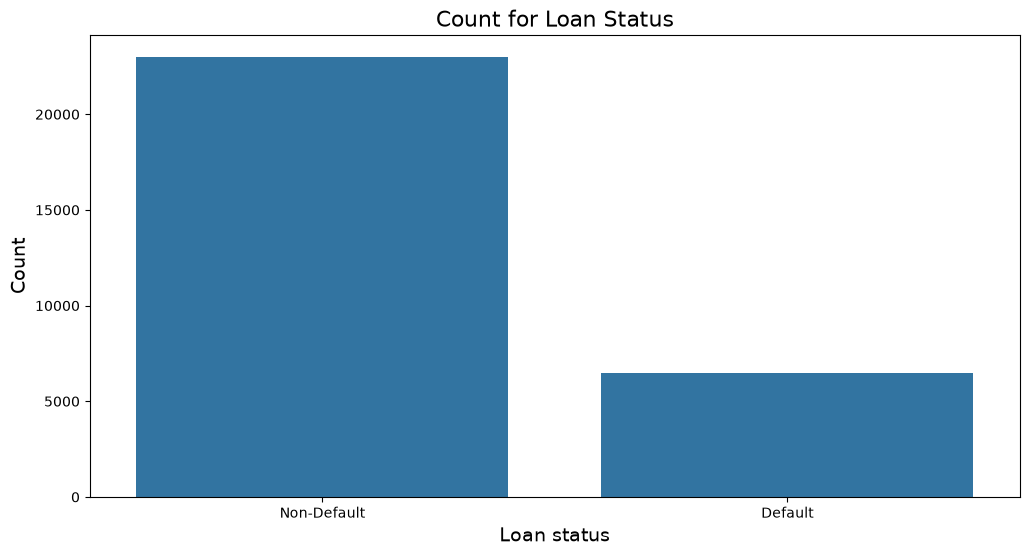

In [65]:
# Target Variable Analysis
# plots count
ax = sns.countplot(x=df_cr_loan['loan_status'])

# sets the figure size in inches
ax.figure.set_size_inches(12, 6)

# set plot features
ax.set_title("Count for Loan Status", fontsize=16)
ax.set_ylabel("Count", fontsize=14)
ax.set_xlabel("Loan status", fontsize=14)

# set xticks labels
plt.xticks([0, 1], ['Non-Default', 'Default'])

# displays plot
plt.show()

In [66]:
df_default = df_cr_loan[df_cr_loan['loan_status'] == 1].copy()
df_non_default = df_cr_loan[df_cr_loan['loan_status'] == 0].copy()

In [67]:
# counts the number of defaults and non-defaults
total_default = df_default.shape[0]
total_non_default = df_non_default.shape[0]
total_loans = df_cr_loan.shape[0]

print('Number of default cases:', total_default)
print('This is equivalent to {:.2f}% of the total loans'.format((total_default/total_loans)*100))

print('\nNumber of non-defualt cases:', total_non_default)
print('This is equivalent to {:.2f}% of the total loans'.format((total_non_default/total_loans)*100))

Number of default cases: 6463
This is equivalent to 21.94% of the total loans

Number of non-defualt cases: 22996
This is equivalent to 78.06% of the total loans


As observed there are many more cases of non-defaulers , thus the dataset is imbalanced

### Numerical variables

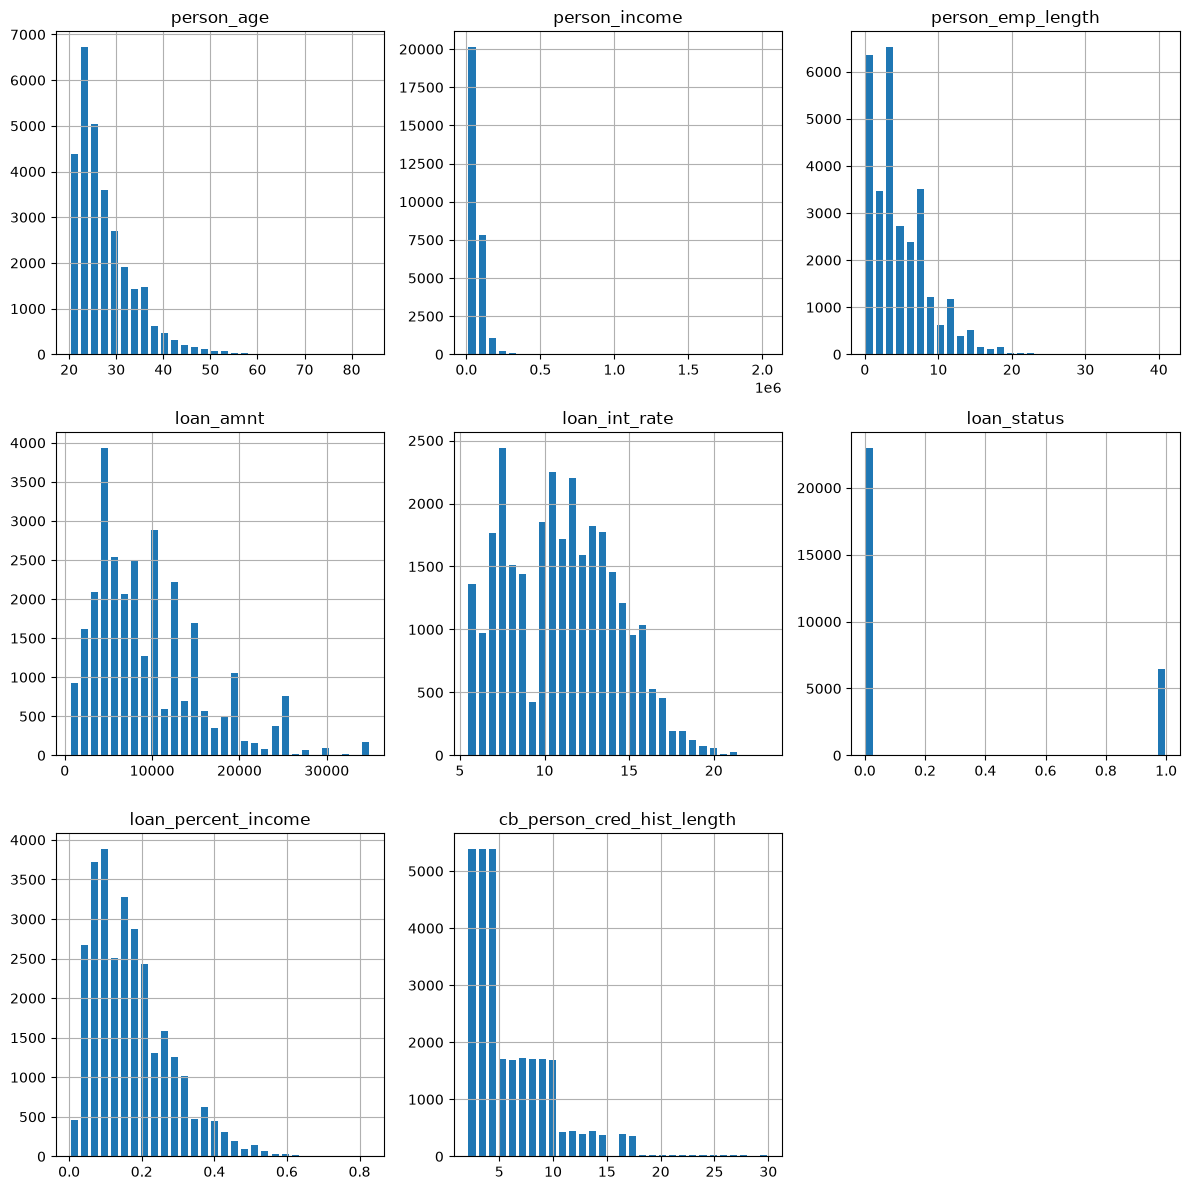

In [72]:
num_attributes = df_cr_loan.select_dtypes(include=['int64', 'float64'])
plot_ = num_attributes.hist(bins=30, figsize=(12,12), rwidth=0.7)
plt.tight_layout()
plt.show()

### Categorical variables

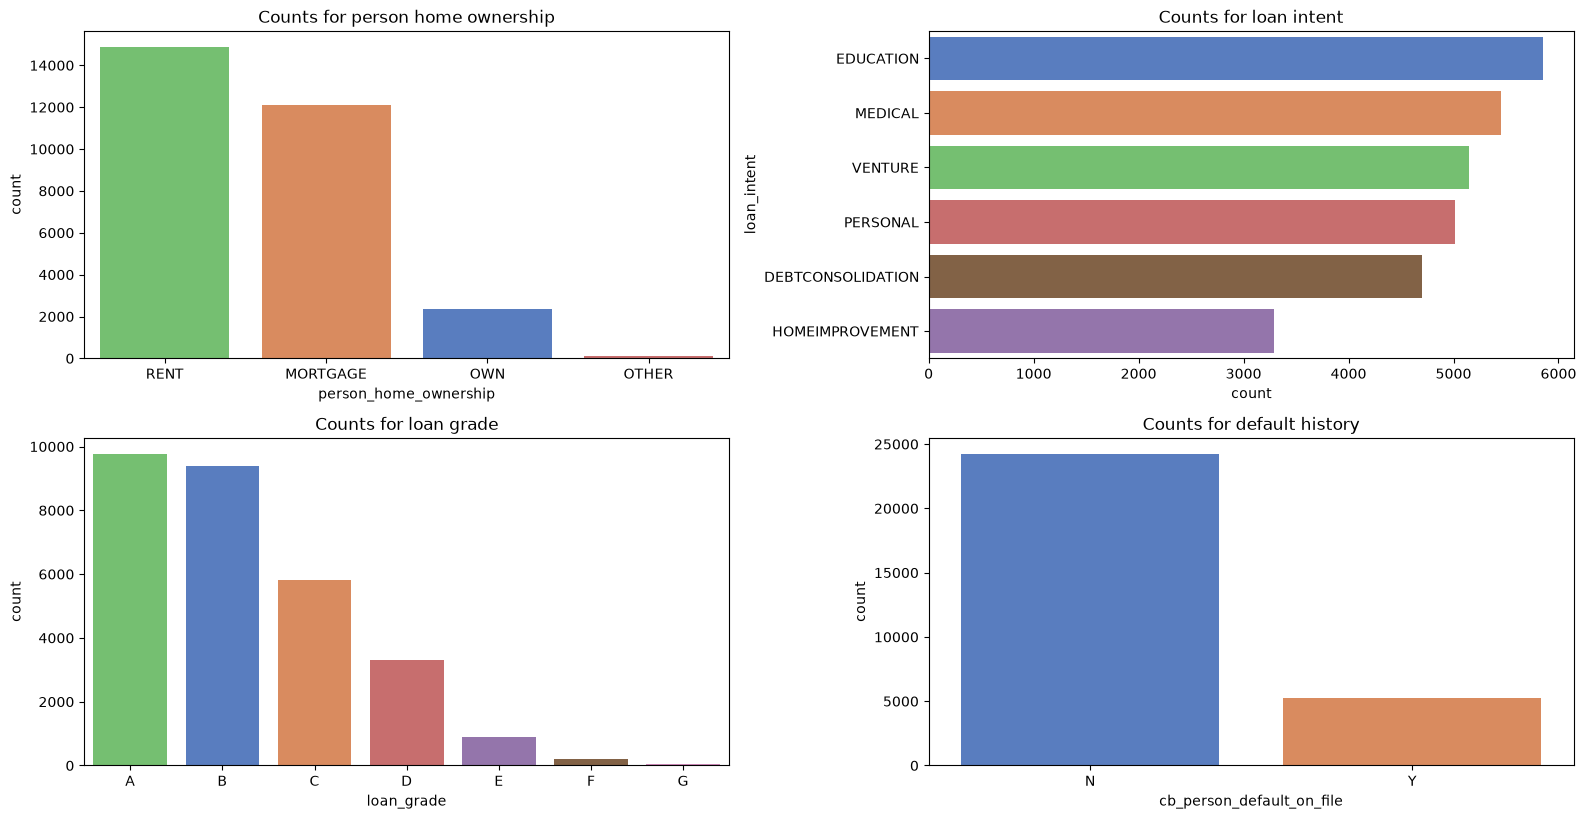

In [74]:
cat_attributes = df_cr_loan.select_dtypes(exclude=['int64', 'float64'])

plt.figure(figsize=(16, 16))

# person_home_ownership
plt.subplot(4, 2, 1)
sns.countplot(x=cat_attributes['person_home_ownership'],
              order=cat_attributes['person_home_ownership'].value_counts().index,
              hue=cat_attributes['person_home_ownership'],
              palette='muted', legend=False)
plt.title("Counts for person home ownership")

# loan_intent
plt.subplot(4, 2, 2)
sns.countplot(y=cat_attributes['loan_intent'],
              order=cat_attributes['loan_intent'].value_counts().index,
              hue=cat_attributes['loan_intent'],
              palette='muted', legend=False)
plt.title("Counts for loan intent")

# loan_grade
plt.subplot(4, 2, 3)
sns.countplot(x=cat_attributes['loan_grade'],
              order=cat_attributes['loan_grade'].value_counts().index,
              hue=cat_attributes['loan_grade'],
              palette='muted', legend=False)
plt.title("Counts for loan grade")

# cb_person_default_on_file
plt.subplot(4, 2, 4)
sns.countplot(x=cat_attributes['cb_person_default_on_file'],
              order=cat_attributes['cb_person_default_on_file'].value_counts().index,
              hue=cat_attributes['cb_person_default_on_file'],
              palette='muted', legend=False)
plt.title("Counts for default history")

plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.tight_layout()
plt.show()

### ***Bivariate Analysis***

### H1. There are more defaults for young people. <font color='green'>(TRUE)

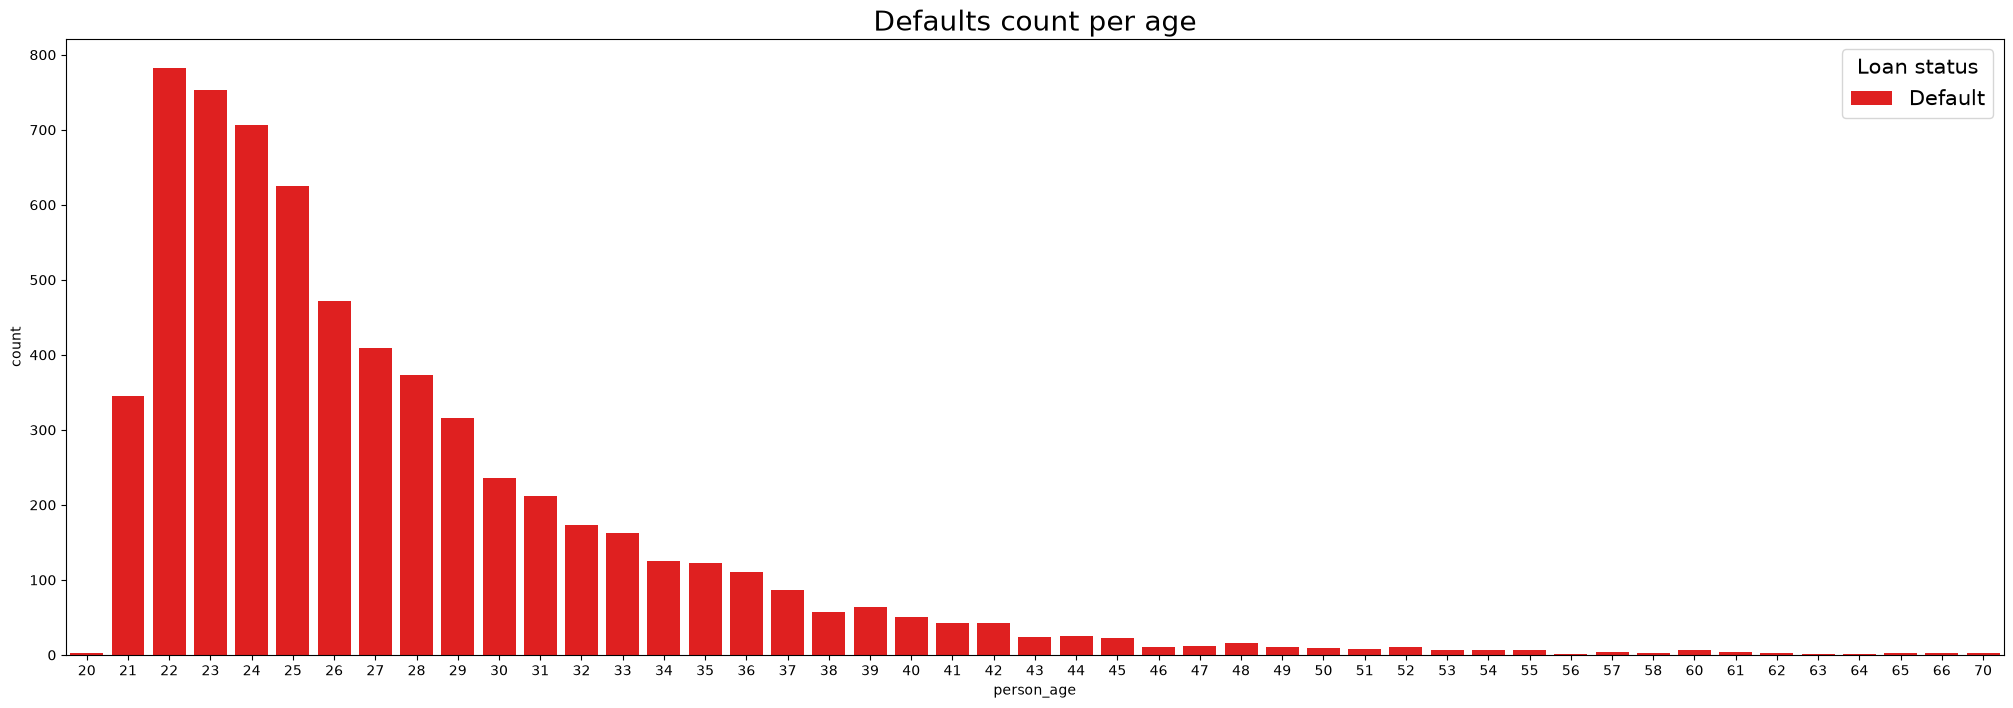

In [76]:
# uses the variable ax for single a Axes
fig, ax = plt.subplots()

# sets the figure size in inches
ax.figure.set_size_inches(25, 8)

# plots the graph
sns.countplot(x='person_age', hue='loan_status', data=df_default, palette=["r"])

# sets plot title
ax.set_title("Defaults count per age", fontsize=20)

# sets the legend
plt.legend(title="Loan status", labels=['Default'], title_fontsize=15, fontsize=15)

# display plots
plt.show()

### H2. People who default have lower income than people who not default. <font color='green'>(TRUE)

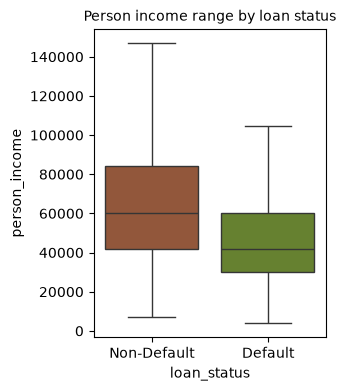

In [119]:
fig, ax = plt.subplots()
ax.figure.set_size_inches(3, 4)

sns.boxplot(x='loan_status', y='person_income', data=df_cr_loan,
            showfliers=False,
            hue='loan_status',
            palette=["#A0522D", "#6B8E23"],  # sienna brown, olive green
            legend=False)

ax.set_title("Person income range by loan status", fontsize=10)
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.show()

### H3. The median percentage of income to the loan is higher for default than the median for non-default. <font color='green'>(TRUE)

C:\Users\piyus\AppData\Local\Temp\ipykernel_38208\2754937748.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='loan_percent_income',  data=df_cr_loan,


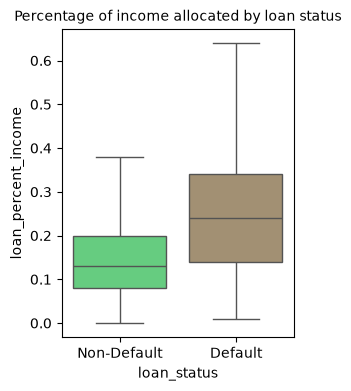

In [120]:
# uses the variable ax for single a Axes
fig, ax = plt.subplots()

# sets the figure size in inches
ax.figure.set_size_inches(3, 4)



# plots the graph
sns.boxplot(x='loan_status', y='loan_percent_income',  data=df_cr_loan, 
            showfliers=False, palette=sns.color_palette("terrain", 2))

# sets plot title
ax.set_title("Percentage of income allocated by loan status", fontsize=10)

# set xticks labels
plt.xticks([0, 1], ['Non-Default', 'Default'])

# display plots
plt.show()

### H4. Mortgage have more cases of default, followed by rent and own. <font color='red'>(FALSE)

C:\Users\piyus\AppData\Local\Temp\ipykernel_38208\3488605960.py:8: UserWarning: The palette list has more values (6) than needed (1), which may not be intended.
  sns.countplot(x='person_home_ownership', hue='loan_status', data=df_default,


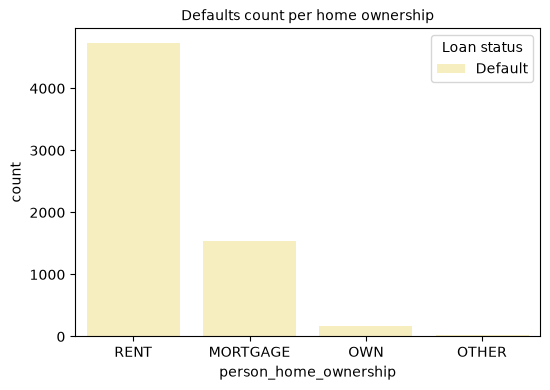

In [126]:
# uses the variable ax for single a Axes
fig, ax = plt.subplots()

# sets the figure size in inches
ax.figure.set_size_inches(6, 4)

# plots the graph
sns.countplot(x='person_home_ownership', hue='loan_status', data=df_default, 
              order=df_default['person_home_ownership'].value_counts().index, palette=sns.color_palette("YlOrBr"))

# sets plot title
ax.set_title("Defaults count per home ownership", fontsize=10)

# sets the legend
plt.legend(title="Loan status", labels=['Default'], title_fontsize=10, fontsize=10)

# display plots
plt.show()

### H5. The are fewer cases of default for people with long employment length. <font color='green'>(TRUE)

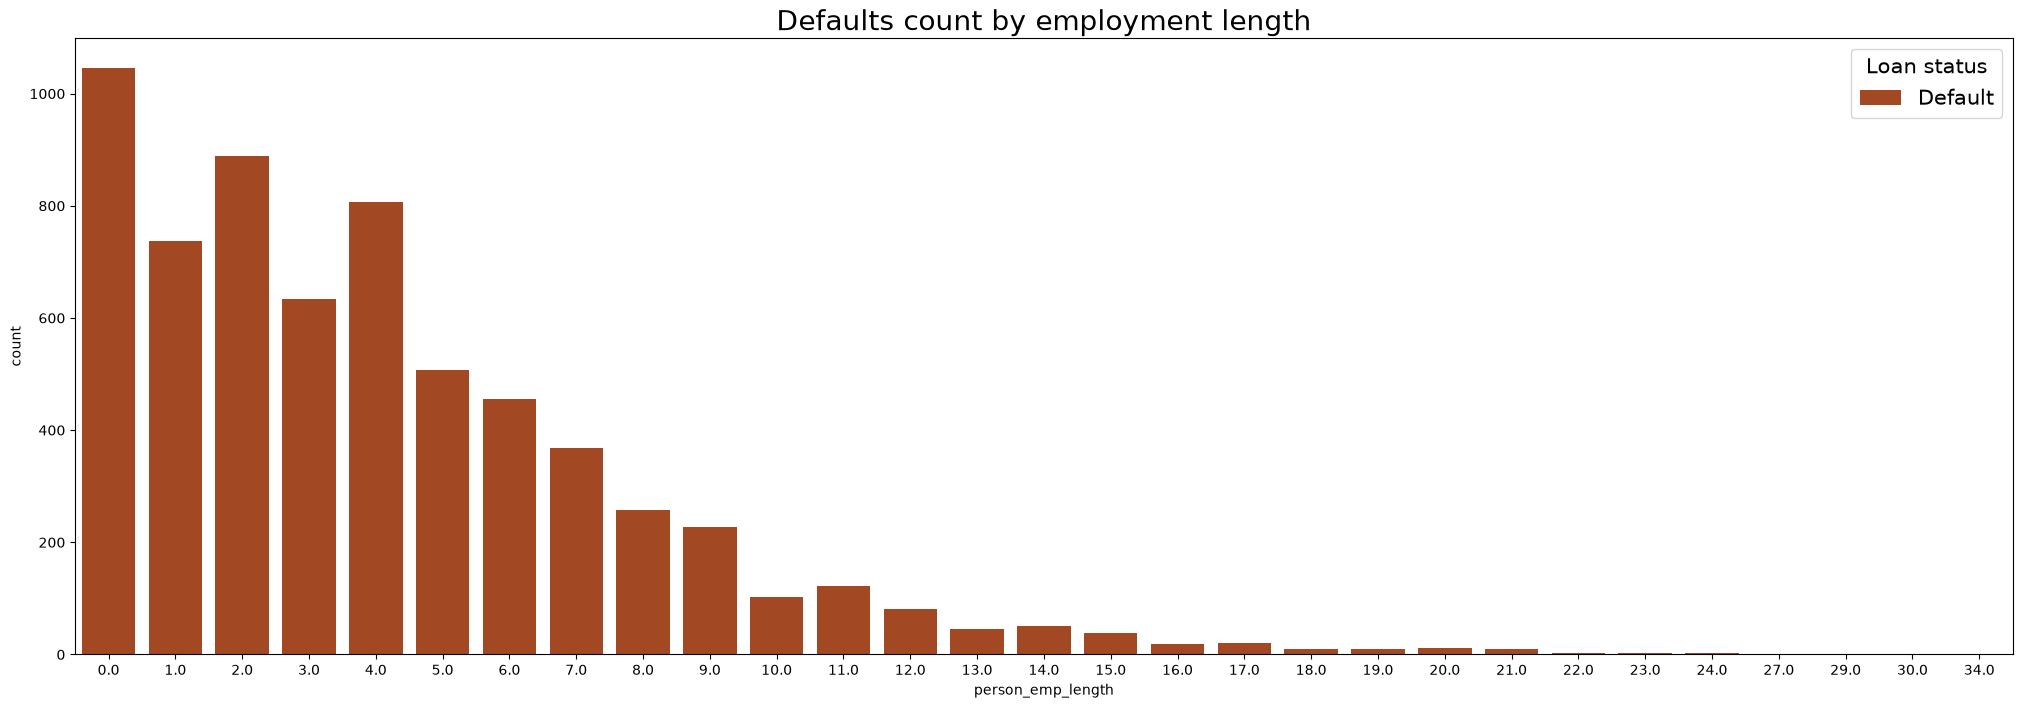

In [87]:
# uses the variable ax for single a Axes
fig, ax = plt.subplots()

# sets the figure size in inches
ax.figure.set_size_inches(25, 8)

# plots the graph
sns.countplot(x='person_emp_length', hue='loan_status', data=df_default, palette=["#B7410E"])

# sets plot title
ax.set_title("Defaults count by employment length", fontsize=20)

# sets the legend
plt.legend(title="Loan status", labels=['Default'], title_fontsize=15, fontsize=15)

# display plots
plt.show()

### H6. There are more cases of default for people having history of default. <font color='red'>(FALSE)

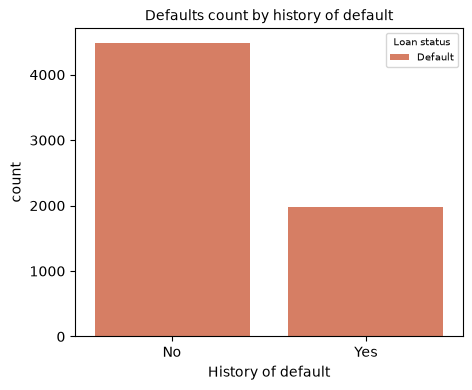

In [98]:
# uses the variable ax for single a Axes
fig, ax = plt.subplots()

# sets the figure size in inches
ax.figure.set_size_inches(5, 4)

# plots the graph
sns.countplot(x='cb_person_default_on_file', hue='loan_status', data=df_default, palette=["#E97451"])

# sets plot title
ax.set_title("Defaults count by history of default", fontsize=10)

# sets the legend
plt.legend(title="Loan status", labels=['Default'], title_fontsize=7, fontsize=7)

plt.xlabel("History of default")

# set xticks labels
plt.xticks([0, 1], ['No', 'Yes'])

# display plots
plt.show()

### H7. There are fewer cases of default for people having longer credit history length. <font color='green'>(TRUE)

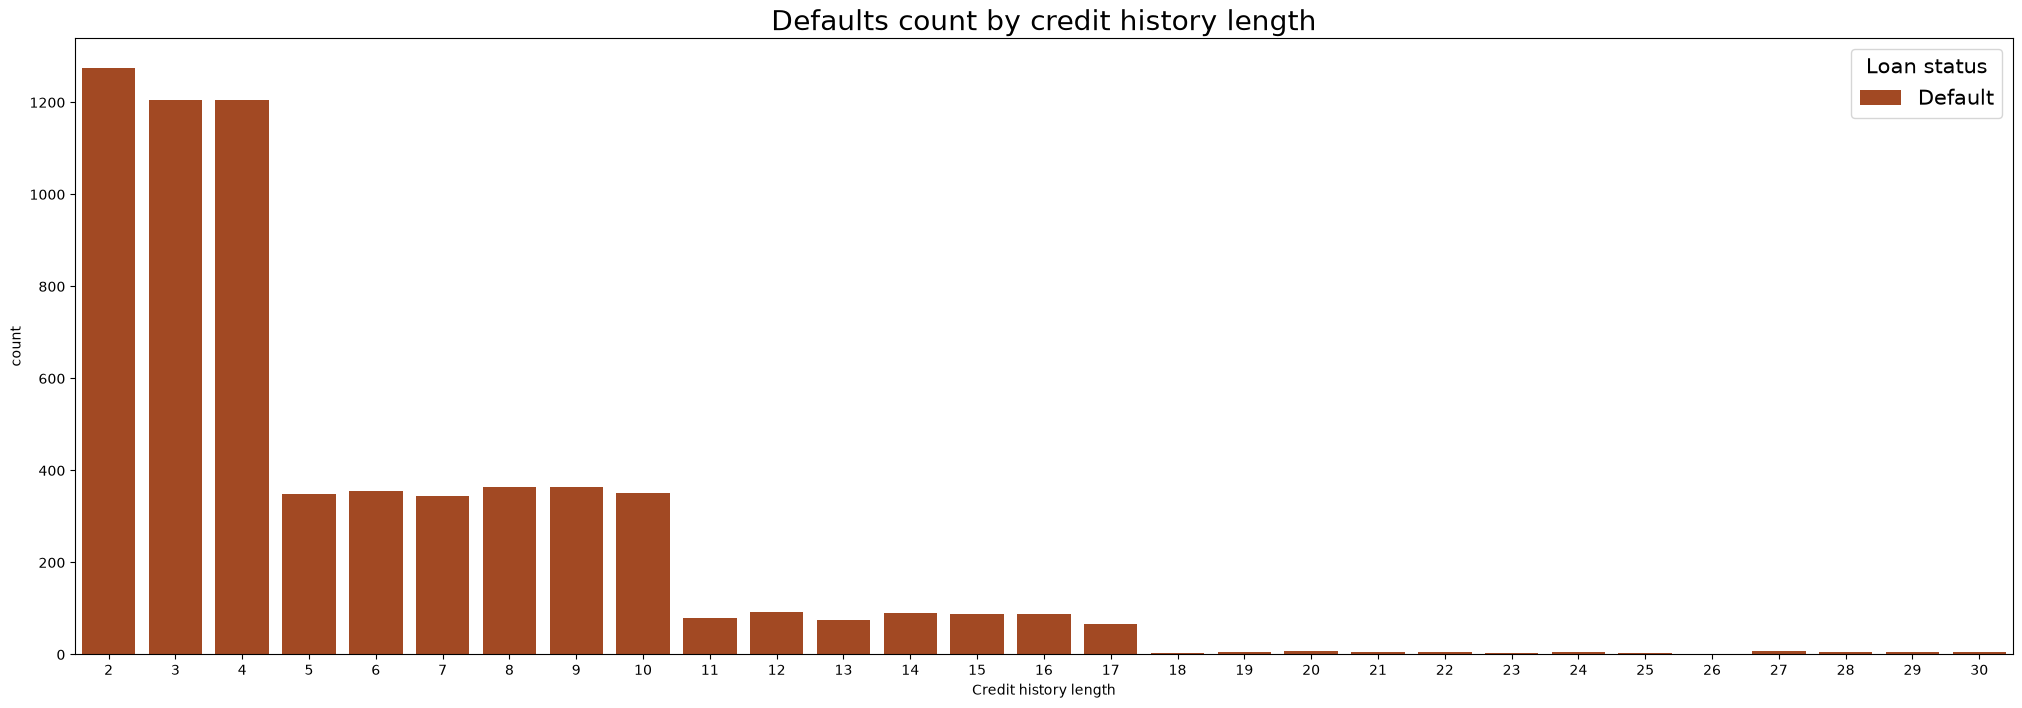

In [100]:
# uses the variable ax for single a Axes
fig, ax = plt.subplots()

# sets the figure size in inches
ax.figure.set_size_inches(25, 8)

# plots the graph
sns.countplot(x='cb_person_cred_hist_length', hue='loan_status', data=df_default, palette=["#B7410E"])

# sets plot title
ax.set_title("Defaults count by credit history length", fontsize=20)

# sets the legend
plt.legend(title="Loan status", labels=['Default'], title_fontsize=15, fontsize=15)

plt.xlabel("Credit history length")

# display plots
plt.show()

### H8. There are more cases of default for personal than any other intent. <font color='red'>(FALSE)</font>
### H9. The least cases of default are for venture. <font color='green'>(TRUE)

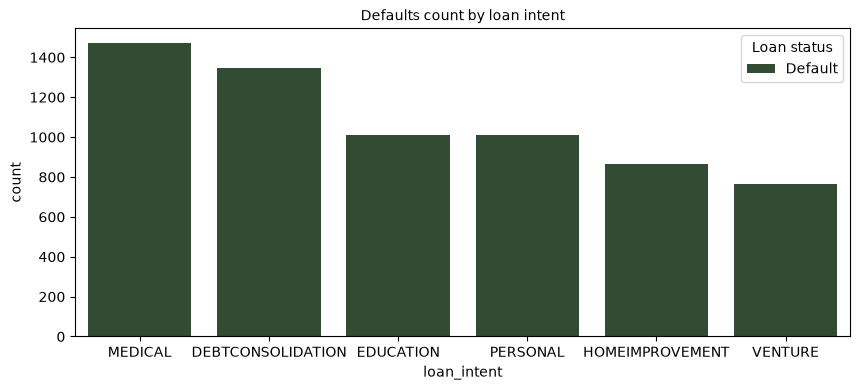

In [129]:
# uses the variable ax for single a Axes
fig, ax = plt.subplots()

# sets the figure size in inches
ax.figure.set_size_inches(10, 4)

# plots the graph
sns.countplot(x='loan_intent', hue='loan_status', data=df_default, 
              order=df_default['loan_intent'].value_counts().index, palette=["#2F4F2F"])

# sets plot title
ax.set_title("Defaults count by loan intent", fontsize=10)

# sets the legend
plt.legend(title="Loan status", labels=['Default'], title_fontsize=10, fontsize=10)

# display plots
plt.show()

### H10. The higher the grade, the fewer are the cases of default. <font color='red'>(FALSE)

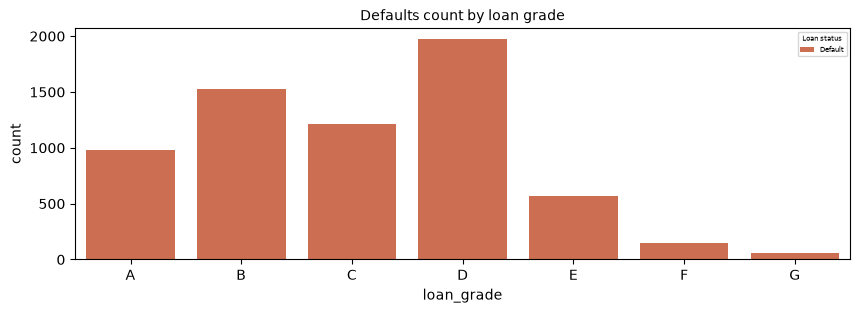

In [108]:
# uses the variable ax for single a Axes
fig, ax = plt.subplots()

# sets the figure size in inches
ax.figure.set_size_inches(10, 3)

# plots the graph
sns.countplot(x='loan_grade', hue='loan_status', data=df_default, 
              order=df_default['loan_grade'].value_counts().index.sort_values(), palette=["#E0633D"])

# sets plot title
ax.set_title("Defaults count by loan grade", fontsize=10)

# sets the legend
plt.legend(title="Loan status", labels=['Default'], title_fontsize=5, fontsize=5)

# display plots
plt.show()

### H11. The loan amount median for default cases is higher than for non-default. <font color='green'>(TRUE)

C:\Users\piyus\AppData\Local\Temp\ipykernel_38208\4160197625.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='loan_amnt',  data=df_cr_loan, showfliers=False, palette=["#00B7C4DA", "#FF7044B4"])


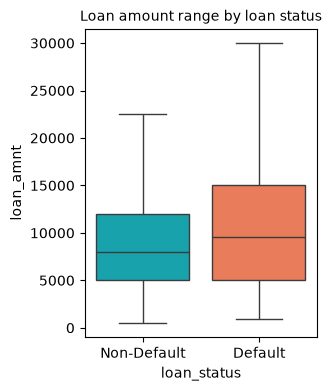

In [114]:
# uses the variable ax for single a Axes
fig, ax = plt.subplots()

# sets the figure size in inches
ax.figure.set_size_inches(3, 4)

# plots the graph
sns.boxplot(x='loan_status', y='loan_amnt',  data=df_cr_loan, showfliers=False, palette=["#00B7C4DA", "#FF7044B4"])

# sets plot title
ax.set_title("Loan amount range by loan status", fontsize=10)

# set xticks labels
plt.xticks([0, 1], ['Non-Default', 'Default'])

# display plots
plt.show()

### H12. The interest rate median for default cases is higher than for non-default. <font color='green'>(TRUE)

C:\Users\piyus\AppData\Local\Temp\ipykernel_38208\1993418538.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='loan_int_rate',  data=df_cr_loan, showfliers=False, palette=["#00B7C4DA", "#FF7044B4"])


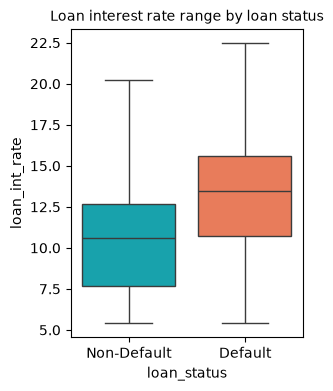

In [117]:
# uses the variable ax for single a Axes
fig, ax = plt.subplots()

# sets the figure size in inches
ax.figure.set_size_inches(3, 4)

# plots the graph
sns.boxplot(x='loan_status', y='loan_int_rate',  data=df_cr_loan, showfliers=False, palette=["#00B7C4DA", "#FF7044B4"])

# sets plot title
ax.set_title("Loan interest rate range by loan status", fontsize=10)

# set xticks labels
plt.xticks([0, 1], ['Non-Default', 'Default'])

# display plots
plt.show()

### ***Multivariate Analysis- Correlations***

#### Correlation between Numerical Attributes

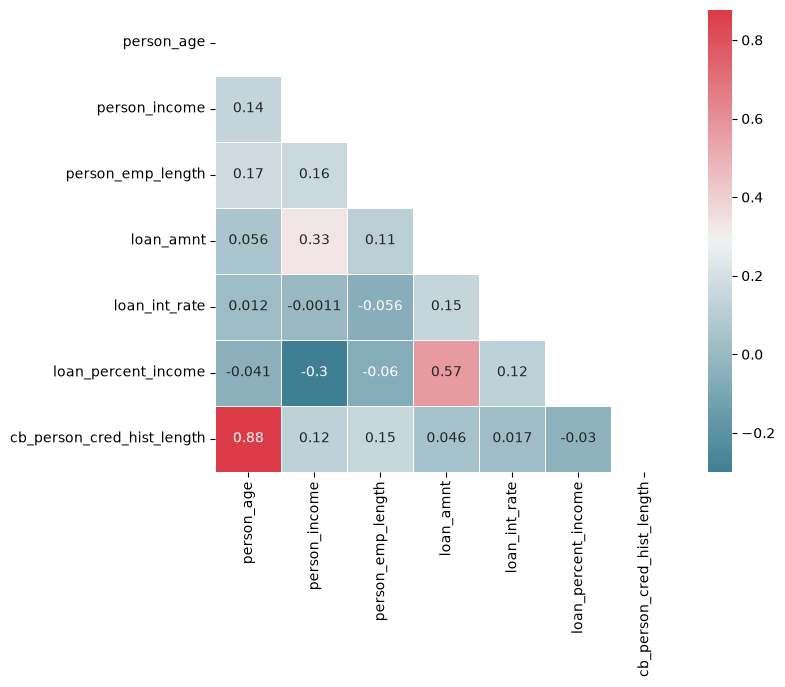

In [ ]:
num_attributes = num_attributes.drop('loan_status', axis=1)

# gets the correlation between the numerical variables
correlation = num_attributes.corr(method='pearson')

# uses the variable ax for single a Axes
fig, ax = plt.subplots()

# sets the figure size in inches
ax.figure.set_size_inches(8, 6)

# generates a mask for the upper triangle
mask = np.triu(np.ones_like(correlation, dtype=np.bool))

# generates a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# plots the heatmap
sns.heatmap(correlation, cmap=cmap, mask=mask, square=True, linewidths=.5, annot=True)

# displays the plot
plt.show()

### ***Data Preprocessing***

In [138]:
df_cr_loan = pd.read_csv('data/cr_loan_clean.csv')
df_cr_loan.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [139]:
df_cr_loan.shape

(29459, 12)

In [143]:
import pickle
import os

df_numerical_vars = df_cr_loan.select_dtypes(include=['int64', 'float64']).drop('loan_status', axis=1)

mms = MinMaxScaler()
scaled_numerical = mms.fit_transform(df_numerical_vars)

# make sure the folder exists before saving into it
os.makedirs('parameter', exist_ok=True)

with open('parameter/numerical_vars_scaler.pkl', 'wb') as f:
    pickle.dump(mms, f)

# gets the Data Frame version of numerical scaled for later manipulation
df_scaled_numerical = pd.DataFrame(scaled_numerical)

# renaming the columns of result Data Frame
df_scaled_numerical.columns = df_numerical_vars.columns

# checks data set size
df_scaled_numerical.shape

(29459, 7)

### ***Transformation***

In [144]:
# creates data sets for non-numeric data
cred_str = df_cr_loan.select_dtypes(include=['object'])

# One-hot encode the non-numeric columns
cred_str_onehot = pd.get_dummies(cred_str)

# union the one-hot encoded columns to the numeric ones
df_cr_loan_prep = pd.concat([df_scaled_numerical, cred_str_onehot], axis=1)

# prints the columns in the new data set
print(df_cr_loan_prep.columns)

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_A',
       'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E',
       'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_N',
       'cb_person_default_on_file_Y'],
      dtype='str')


C:\Users\piyus\AppData\Local\Temp\ipykernel_38208\1663336903.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cred_str = df_cr_loan.select_dtypes(include=['object'])


In [146]:
loan_status = df_cr_loan[['loan_status']].copy()

df_cr_loan_prep = pd.concat([loan_status, df_cr_loan_prep], axis=1)

df_cr_loan_prep.info()

<class 'pandas.DataFrame'>
RangeIndex: 29459 entries, 0 to 29458
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   loan_status                     29459 non-null  int64  
 1   person_age                      29459 non-null  float64
 2   person_income                   29459 non-null  float64
 3   person_emp_length               29459 non-null  float64
 4   loan_amnt                       29459 non-null  float64
 5   loan_int_rate                   29459 non-null  float64
 6   loan_percent_income             29459 non-null  float64
 7   cb_person_cred_hist_length      29459 non-null  float64
 8   person_home_ownership_MORTGAGE  29459 non-null  bool   
 9   person_home_ownership_OTHER     29459 non-null  bool   
 10  person_home_ownership_OWN       29459 non-null  bool   
 11  person_home_ownership_RENT      29459 non-null  bool   
 12  loan_intent_DEBTCONSOLIDATION   29459 non-n

In [147]:
# checkpoint
df_cr_loan_prep.to_csv('data/cr_loan_prep.csv', index=False)

### ***Model Building***

In [148]:
df_cr_loan = pd.read_csv('data/cr_loan_prep.csv')

df_cr_loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 29459 entries, 0 to 29458
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   loan_status                     29459 non-null  int64  
 1   person_age                      29459 non-null  float64
 2   person_income                   29459 non-null  float64
 3   person_emp_length               29459 non-null  float64
 4   loan_amnt                       29459 non-null  float64
 5   loan_int_rate                   29459 non-null  float64
 6   loan_percent_income             29459 non-null  float64
 7   cb_person_cred_hist_length      29459 non-null  float64
 8   person_home_ownership_MORTGAGE  29459 non-null  bool   
 9   person_home_ownership_OTHER     29459 non-null  bool   
 10  person_home_ownership_OWN       29459 non-null  bool   
 11  person_home_ownership_RENT      29459 non-null  bool   
 12  loan_intent_DEBTCONSOLIDATION   29459 non-n

In [149]:
# Train Test Split

X = df_cr_loan.drop('loan_status', axis=1).values
y = df_cr_loan['loan_status'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,random_state=42, stratify=y)

As we saw earlier the ds is imbalaned ,so balancing the Data using SMOTE

In [152]:
from imblearn.combine import SMOTETomek

# counts the number of classes before oversampling
print('Before balancing:', Counter(y_train))

# defines the resampler
resampler = SMOTETomek(random_state=42, n_jobs=-1)

# transforms the data set
X_balanced, y_balanced = resampler.fit_resample(X_train, y_train)

# counts the number of classes after oversampling
print('After balancing:', Counter(y_balanced))

Before balancing: Counter({np.int64(0): 17247, np.int64(1): 4847})
After balancing: Counter({np.int64(0): 16981, np.int64(1): 16981})


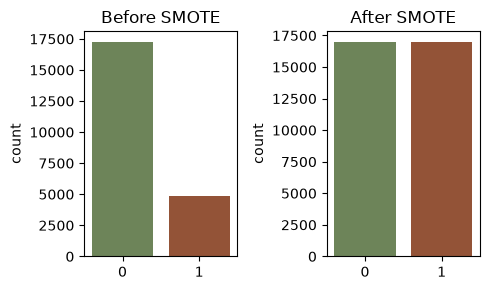

Total records BEFORE: 22094
Total records AFTER: 33962
Difference = -11868


In [161]:
plt.figure(figsize=(5,3))

plt.subplot(1,2,1)
sns.countplot(x=y_train, hue=y_train, palette=["#6C8B52", "#A24D28"], legend=False)
plt.title("Before SMOTE")

plt.subplot(1,2,2)
sns.countplot(x=y_balanced, hue=y_balanced, palette=["#6C8B52", "#A24D28"], legend=False)
plt.title("After SMOTE")

plt.tight_layout()
plt.show()

print("Total records BEFORE:", X_train.shape[0])
print("Total records AFTER:", X_balanced.shape[0])
print("Difference =", X_train.shape[0] - X_balanced.shape[0])

In [162]:
# Set the threshold for defaults
THRESHOLD = 0.45

In [164]:
classifiers = [LogisticRegression(max_iter=220, random_state=42),
               RandomForestClassifier(random_state=42),
               xgb.XGBClassifier(random_state=42),
               CatBoostClassifier(random_state=42, verbose=False)]

In [165]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
import pandas as pd

def get_classifiers_performance(X_train, X_test, y_train, y_test, threshold, classifiers):
    """
    classifiers: dict like {"Logistic Regression": lr_model, "Random Forest": rf_model, ...}
    Assumes each model is already fitted, or fits it here if not.
    """
    results = []

    for name, model in classifiers.items():
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "ROC AUC": roc_auc_score(y_test, y_proba)
        })

    df_performances = pd.DataFrame(results).set_index("Model")
    return df_performances

In [180]:

SEED = 42
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED),
    "XGBoost": XGBClassifier(random_state=SEED, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(random_state=SEED, verbose=0)
}

df_performances = get_classifiers_performance(X_balanced, X_test, y_balanced, y_test, 0.45, classifiers)
df_performances

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.789817,0.513567,0.796411,0.624454,0.872637
Random Forest,0.916497,0.848780,0.753713,0.798427,0.930397
XGBoost,0.930482,0.935331,0.733911,0.822469,0.942171
CatBoost,0.934555,0.960227,0.732054,0.830758,0.942428


As observed, for the context of our project, we are aiming for recall. `LogisticRegression` presents the highest recall score. However, it's precision score is the lowest. Let's assume we are aiming more for recall and moderate to precision, we could then, take advantage of f1-score, as it's the harmonic average between precision and recall. Thus, the algorithm that satisfies this need is `CatBoostClassifier`.

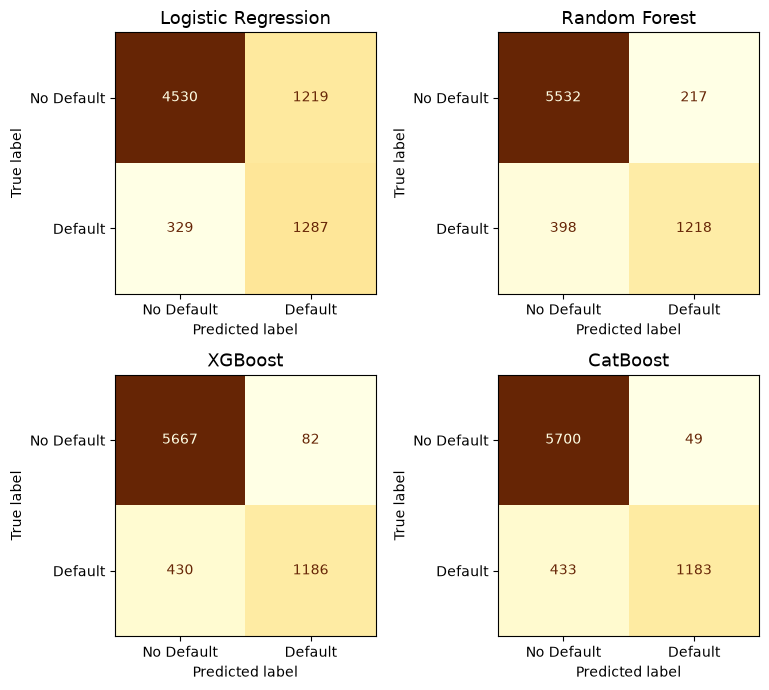

In [184]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()

for idx, (name, model) in enumerate(classifiers.items()):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= THRESHOLD).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=axes[idx], cmap='YlOrBr', colorbar=False)
    axes[idx].set_title(name, fontsize=13)

plt.tight_layout()
plt.show()

In [185]:
# instantiates the classifiers
lr_clf = LogisticRegression(max_iter=220, random_state=SEED)
rf_clf = RandomForestClassifier(random_state=SEED)
xgb_clf = xgb.XGBClassifier(random_state=SEED)
catb_clf = CatBoostClassifier(random_state=SEED, verbose=False)


# trains the classifiers
lr_clf.fit(X_balanced, y_balanced)
rf_clf.fit(X_balanced, y_balanced)
xgb_clf.fit(X_balanced, y_balanced)
catb_clf.fit(X_balanced, y_balanced)


# store the predicted probabilities for class 1
y_pred_lr_prob = lr_clf.predict_proba(X_test)[:, 1]
y_pred_rf_prob = rf_clf.predict_proba(X_test)[:, 1]
y_pred_xgb_prob = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_catb_prob = catb_clf.predict_proba(X_test)[:,1]

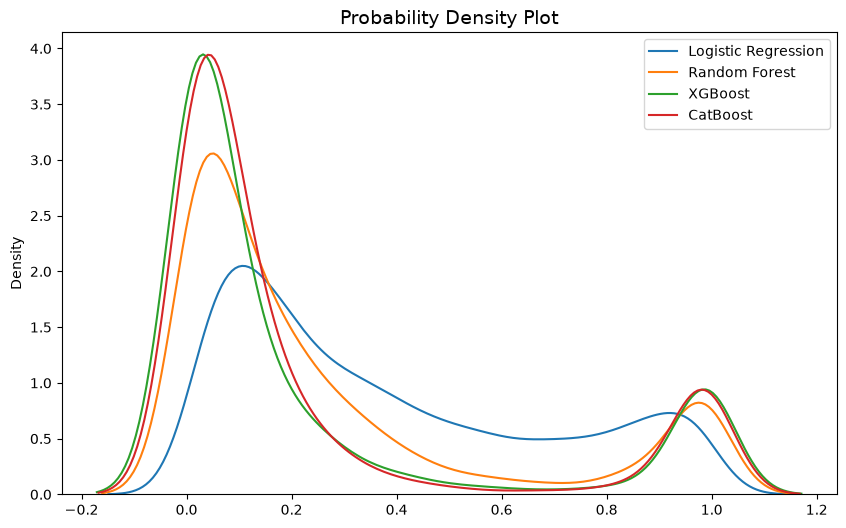

In [186]:
# sets plot size
plt.figure(figsize=(10,6))

# plots
sns.kdeplot(y_pred_lr_prob, label='Logistic Regression')
sns.kdeplot(y_pred_rf_prob, label='Random Forest')
sns.kdeplot(y_pred_xgb_prob, label='XGBoost')
sns.kdeplot(y_pred_catb_prob, label='CatBoost')

# sets the plot features
plt.title("Probability Density Plot", fontsize=14)
plt.legend()

# displays the plot
plt.show()

As we can see `Logisstic Reg` is showing moderaly distributed probablity  `RandomForest` seems to be the mid-term between the other two, but its F1-Score precision score aren't satisfactory enough to consider it, as we compared with other algorithms. The mid-term between `XGBoost` and `RandomForest` is `CatBoost` which suits best for the context and challenge of our project.

In [192]:
# makes predictions
y_pred_lr= lr_clf.predict(X_test)
y_pred_rf= rf_clf.predict(X_test)
y_pred_xgb = xgb_clf.predict(X_test)
y_pred_catb = catb_clf.predict(X_test)

print('Classification Report for ' + type(lr_clf).__name__)
print(classification_report(y_test, y_pred_lr))

print('\nClassification Report for ' + type(rf_clf).__name__)
print(classification_report(y_test, y_pred_rf))

print('\nClassification Report for ' + type(xgb_clf).__name__)
print(classification_report(y_test, y_pred_xgb))

print('\nClassification Report for ' + type(catb_clf).__name__)
print(classification_report(y_test, y_pred_catb))

Classification Report for LogisticRegression
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5749
           1       0.55      0.77      0.64      1616

    accuracy                           0.81      7365
   macro avg       0.74      0.80      0.76      7365
weighted avg       0.84      0.81      0.82      7365


Classification Report for RandomForestClassifier
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      5749
           1       0.90      0.74      0.81      1616

    accuracy                           0.92      7365
   macro avg       0.91      0.86      0.88      7365
weighted avg       0.92      0.92      0.92      7365


Classification Report for XGBClassifier
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5749
           1       0.95      0.72      0.82      1616

    accuracy                           0.93   

As we analyzed before, we're looking for high f1-score. Although `XGBoost` and `CatBoost` seems to have equal values for f1-score, looking at the precision score, `CatBoost` gives us a better result.

### ***Cross Validation Scoring - CatBoostClassifier***

In [193]:
print(f'Ratio of negatives in full data set: {pd.DataFrame(y)[0].value_counts(normalize=True).to_dict()[0]}')
print(f'Ratio of positives in full data set: {pd.DataFrame(y)[0].value_counts(normalize=True).to_dict()[1]}')

Ratio of negatives in full data set: 0.7806103397942904
Ratio of positives in full data set: 0.21938966020570963


In [195]:
cv = StratifiedKFold(n_splits=10)

# calculates the cross validation scores
cv_scores = cross_val_score(catb_clf, X, np.ravel(y), cv = cv, scoring='precision', n_jobs=-1)

# prints the average precision and standard deviation of the scores
print("Average precision: %0.4f (+/- %0.4f)" % (cv_scores.mean(), cv_scores.std() * 2))


# calculates the cross validation scores
cv_scores = cross_val_score(catb_clf, X, np.ravel(y), cv = cv, scoring='recall', n_jobs=-1)

# prints the average recall and standard deviation of the scores
print("\nAverage recall: %0.4f (+/- %0.4f)" % (cv_scores.mean(), cv_scores.std() * 2))


# calculates the cross validation scores
cv_scores = cross_val_score(catb_clf, X, np.ravel(y), cv = cv, scoring='f1', n_jobs=-1)

# prints the average f1-score and standard deviation of the scores
print("\nAverage f1-score: %0.4f (+/- %0.4f)" % (cv_scores.mean(), cv_scores.std() * 2))


# calculates the cross validation scores
cv_scores = cross_val_score(catb_clf, X, np.ravel(y), cv = cv, scoring='roc_auc', n_jobs=-1)

# prints the average roc_auc and standard deviation of the scores
print("\nAverage ROC AUC: %0.4f (+/- %0.4f)" % (cv_scores.mean(), cv_scores.std() * 2))

Average precision: 0.8853 (+/- 0.1878)

Average recall: 0.7190 (+/- 0.1791)

Average f1-score: 0.7861 (+/- 0.0927)

Average ROC AUC: 0.9048 (+/- 0.0999)


### ***Hyperparameter Tuning***

In [196]:
catb_clf = CatBoostClassifier(random_state=42, verbose=False)

In [197]:
# set up space dictionary with specified hyperparameters
space = {'max_depth': np.arange(2, 10, 2),
         'min_data_in_leaf': [4, 8, 10],
         'learning_rate': np.linspace(0.001, 0.6, 15),
         'subsample': np.linspace(0.25, 1, 15),
         'n_estimators': np.arange(10, 105, 15)}

In [198]:
# prepares RandomizedSearchCV object
catb_clf_cv = RandomizedSearchCV(estimator=catb_clf, param_distributions=space,
                                scoring='f1', n_iter=10, cv=5, verbose=2, 
                                random_state=42, n_jobs=-1)

In [199]:
# fits the RandomizedSearchCV object
catb_clf_cv.fit(X_balanced, y_balanced)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostClass...verbose=False)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': array([0.001 ..., 0.6 ]), 'max_depth': array([2, 4, 6, 8]), 'min_data_in_leaf': [4, 8, ...], 'n_estimators': array([ 10, ...70, 85, 100]), ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be s

In [200]:
catb_clf_cv.best_estimator_

CatBoostClassifier(learning_rate=np.float64(0.3860714285714285), max_depth=np.int64(4), min_data_in_leaf=10, n_estimators=np.int64(100), random_state=42, subsample=np.float64(0.7321428571428571), verbose=False)

In [202]:
print("\nTuned Parameters: {}".format(catb_clf_cv.best_params_)) 
print("\nBest score: {:.4f}".format(catb_clf_cv.best_score_))


Tuned Parameters: {'subsample': np.float64(0.7321428571428571), 'n_estimators': np.int64(100), 'min_data_in_leaf': 10, 'max_depth': np.int64(4), 'learning_rate': np.float64(0.3860714285714285)}

Best score: 0.9461


### ***ROC Curve***

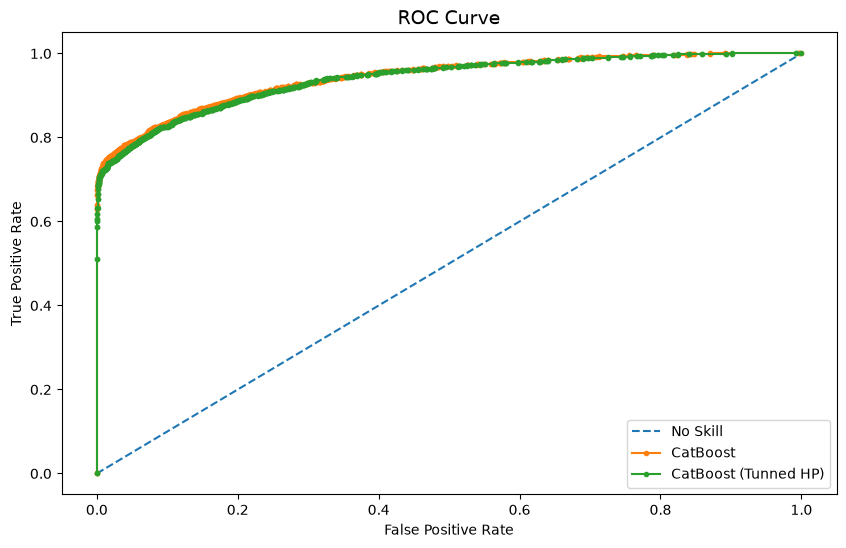

In [203]:
# uses the variable ax for single a Axes
fig, ax = plt.subplots()

# sets the figure size in inches
ax.figure.set_size_inches(10, 6)

# generate a no skill prediction (majority class)
ns_probs = [0 for _ in range(len(y_test))]

# predict probabilities
catb_tuned_model_probs = catb_tuned_model.predict_proba(X_test)

# calculates the roc curves
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
catb_fpr, catb_tpr, _ = roc_curve(y_test, y_pred_catb_prob)
tuned_fpr, tuned_tpr, _ = roc_curve(y_test, catb_tuned_model_probs[:,1])

# plots the roc curve for the model
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
plt.plot(catb_fpr, catb_tpr, marker='.', label='CatBoost')
plt.plot(tuned_fpr, tuned_tpr, marker='.', label='CatBoost (Tunned HP)')

# sets plot features
plt.title("ROC Curve", fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# displays the legend
plt.legend()

# displays the plot
plt.show()

### Cross validation Scoring to check overall performance

In [204]:
cv = StratifiedKFold(n_splits=10)

In [205]:

catb_tuned_model = catb_clf_cv.best_estimator_
# calculates the cross validation scores
cv_scores = cross_val_score(catb_tuned_model, X, np.ravel(y), cv = cv, scoring='precision', n_jobs=-1)

# prints the average precision and standard deviation of the scores
print("Average precision: %0.4f (+/- %0.4f)" % (cv_scores.mean(), cv_scores.std() * 2))


# calculates the cross validation scores
cv_scores = cross_val_score(catb_tuned_model, X, np.ravel(y), cv = cv, scoring='recall', n_jobs=-1)

# prints the average recall and standard deviation of the scores
print("\nAverage recall: %0.4f (+/- %0.4f)" % (cv_scores.mean(), cv_scores.std() * 2))


# calculates the cross validation scores
cv_scores = cross_val_score(catb_tuned_model, X, np.ravel(y), cv = cv, scoring='f1', n_jobs=-1)

# prints the average f1-score and standard deviation of the scores
print("\nAverage f1-score: %0.4f (+/- %0.4f)" % (cv_scores.mean(), cv_scores.std() * 2))


# calculates the cross validation scores
cv_scores = cross_val_score(catb_tuned_model, X, np.ravel(y), cv = cv, scoring='roc_auc', n_jobs=-1)

# prints the average roc_auc and standard deviation of the scores
print("\nAverage ROC AUC: %0.4f (+/- %0.4f)" % (cv_scores.mean(), cv_scores.std() * 2))

Average precision: 0.9192 (+/- 0.1302)

Average recall: 0.7203 (+/- 0.1715)

Average f1-score: 0.8020 (+/- 0.0771)

Average ROC AUC: 0.9108 (+/- 0.0774)


In [207]:
# saves the best model
pickle.dump(catb_tuned_model, open('model/model_credit_risk.pkl', 'wb'))

In [210]:
os.makedirs('parameter', exist_ok=True)
train_columns = df_cr_loan.drop('loan_status', axis=1).columns.tolist()

os.makedirs('parameter', exist_ok=True)
with open('parameter/train_columns.pkl', 'wb') as f:
    pickle.dump(train_columns, f)

print(train_columns)

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_N', 'cb_person_default_on_file_Y']


In [ ]:
train_columns = df_cr_loan.drop('loan_status', axis=1).columns.tolist()

os.makedirs('parameter', exist_ok=True)
with open('parameter/train_columns.pkl', 'wb') as f:
    pickle.dump(train_columns, f)



In [5]:
df_ = pd.read_csv('data/cr_loan_clean.csv')
df_.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [6]:
df_app_time = df_.drop(columns=['loan_grade', 'loan_int_rate']).copy()
 
# numerical columns for THIS model (no loan_int_rate)
numerical_cols_v2 = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length'
]
 
scaler_v2 = MinMaxScaler()
scaled_numerical_v2 = scaler_v2.fit_transform(df_app_time[numerical_cols_v2])
df_scaled_numerical_v2 = pd.DataFrame(scaled_numerical_v2, columns=numerical_cols_v2)
 
# categorical columns (no loan_grade)
cat_cols_v2 = df_app_time.select_dtypes(include=['object', 'str']).columns.tolist()
if 'loan_status' in cat_cols_v2:
    cat_cols_v2.remove('loan_status')
 
df_categorical_v2 = pd.get_dummies(df_app_time[cat_cols_v2])
 
df_app_time_prep = pd.concat(
    [df_scaled_numerical_v2, df_categorical_v2, df_app_time['loan_status'].reset_index(drop=True)],
    axis=1
)
 
print(df_app_time_prep.columns.tolist())
print(df_app_time_prep.shape)

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'cb_person_default_on_file_N', 'cb_person_default_on_file_Y', 'loan_status']
(29459, 19)


In [7]:
from imblearn.combine import SMOTETomek

X_v2 = df_app_time_prep.drop('loan_status', axis=1)
y_v2 = df_app_time_prep['loan_status']
 
train_columns_v2 = X_v2.columns.tolist()  # save column list BEFORE any .values conversion
 
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.25, random_state=42, stratify=y_v2
)
 
resampler_v2 = SMOTETomek(random_state=42, n_jobs=-1)
X_balanced_v2, y_balanced_v2 = resampler_v2.fit_resample(X_train_v2, y_train_v2)
 
print('Before balancing:', y_train_v2.value_counts().to_dict())
print('After balancing:', y_balanced_v2.value_counts().to_dict())

Before balancing: {0: 17247, 1: 4847}
After balancing: {0: 16791, 1: 16791}


In [8]:

catb_app_model = CatBoostClassifier(random_state=42, verbose=0)
catb_app_model.fit(X_balanced_v2, y_balanced_v2)
 
y_proba_app = catb_app_model.predict_proba(X_test_v2)[:, 1]
y_pred_app = (y_proba_app >= 0.5).astype(int)
 
print(classification_report(y_test_v2, y_pred_app))
print("ROC-AUC:", roc_auc_score(y_test_v2, y_proba_app))
print(confusion_matrix(y_test_v2, y_pred_app))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      5749
           1       0.88      0.57      0.69      1616

    accuracy                           0.89      7365
   macro avg       0.89      0.77      0.81      7365
weighted avg       0.89      0.89      0.88      7365

ROC-AUC: 0.8958263727312025
[[5624  125]
 [ 695  921]]


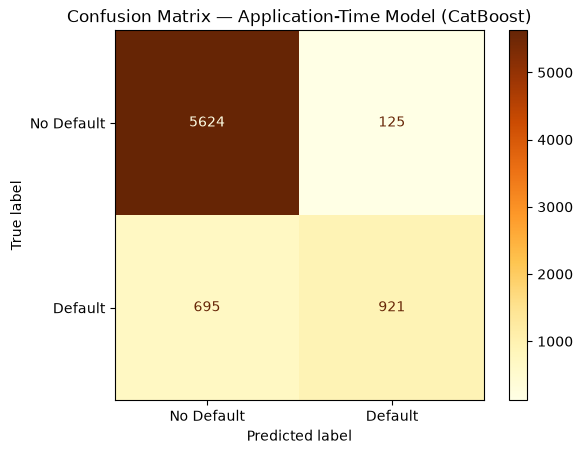

In [9]:
cm = confusion_matrix(y_test_v2, y_pred_app)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='YlOrBr')
plt.title("Confusion Matrix — Application-Time Model (CatBoost)")
plt.show()

In [13]:
calibrated_app_model = CalibratedClassifierCV(catb_app_model, method='sigmoid', cv=5)
calibrated_app_model.fit(X_balanced_v2, y_balanced_v2)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","CatBoostClass...42, verbose=0)"
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...0024894235DF0>, <

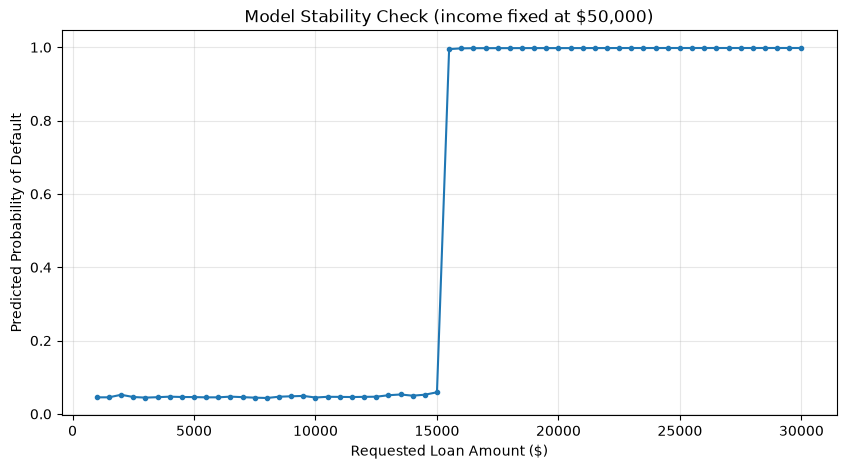

In [17]:

import numpy as np
import matplotlib.pyplot as plt
 
fixed_income = 50000
 
loan_amounts = np.arange(1000, 30001, 500)
probs = []
 
for amt in loan_amounts:
    row = {
        'person_age': 30,
        'person_income': fixed_income,
        'person_home_ownership': 'RENT',
        'person_emp_length': 5.0,
        'loan_intent': 'PERSONAL',
        'loan_amnt': amt,
        'loan_percent_income': amt / fixed_income,
        'cb_person_default_on_file': 'N',
        'cb_person_cred_hist_length': 5,
    }
    df_row = pd.DataFrame([row])
 
    # rebuild the same transform steps as pipeline.py, inline for testing
    numerical_cols_v2 = ['person_age', 'person_income', 'person_emp_length',
                          'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']
    scaled = scaler_v2.transform(df_row[numerical_cols_v2])
    df_scaled = pd.DataFrame(scaled, columns=numerical_cols_v2)
 
    cat_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
    df_cat = pd.get_dummies(df_row[cat_cols])
 
    df_final = pd.concat([df_scaled, df_cat], axis=1)
    df_final = df_final.reindex(columns=train_columns_v2, fill_value=0)
 
    prob = calibrated_app_model.predict_proba(df_final)[0, 1]
    probs.append(prob)
 
plt.figure(figsize=(10, 5))
plt.plot(loan_amounts, probs, marker='o', markersize=3)
plt.xlabel("Requested Loan Amount ($)")
plt.ylabel("Predicted Probability of Default")
plt.title(f"Model Stability Check (income fixed at ${fixed_income:,})")
plt.grid(alpha=0.3)
plt.show()

In [12]:
 
full_probs_v2 = calibrated_app_model.predict_proba(X_v2)[:, 1]
 
df_grade_lookup_v2 = pd.DataFrame({
    'loan_grade': df_['loan_grade'].values,
    'pred_prob': full_probs_v2,
    'loan_int_rate': df_['loan_int_rate'].values
})
 
grade_stats_v2 = df_grade_lookup_v2.groupby('loan_grade').agg(
    avg_prob=('pred_prob', 'mean'),
    avg_rate=('loan_int_rate', 'mean')
).sort_values('avg_prob')
 
print(grade_stats_v2)
 
grades_sorted_v2 = grade_stats_v2.index.tolist()
avg_probs_sorted_v2 = grade_stats_v2['avg_prob'].tolist()
 
thresholds_v2 = []
for i in range(len(avg_probs_sorted_v2) - 1):
    midpoint = (avg_probs_sorted_v2[i] + avg_probs_sorted_v2[i + 1]) / 2
    thresholds_v2.append(midpoint)
 
grade_mapping_v2 = {
    'grades_sorted': grades_sorted_v2,
    'thresholds': thresholds_v2,
    'avg_rate_by_grade': grade_stats_v2['avg_rate'].to_dict(),
}

            avg_prob   avg_rate
loan_grade                     
A           0.133157   7.327732
B           0.174081  10.995542
C           0.253039  13.463649
D           0.384727  15.361250
E           0.400099  17.009455
F           0.416876  18.609159
G           0.504895  20.251525


In [16]:
import os 
import pickle 

os.makedirs('model', exist_ok=True)
os.makedirs('parameter', exist_ok=True)
 
with open('model/model_application_time.pkl', 'wb') as f:
    pickle.dump(calibrated_app_model, f)
 
with open('parameter/scaler_application_time.pkl', 'wb') as f:
    pickle.dump(scaler_v2, f)
 
with open('parameter/train_columns_application_time.pkl', 'wb') as f:
    pickle.dump(train_columns_v2, f)
 
with open('parameter/grade_mapping.pkl', 'wb') as f:
    pickle.dump(grade_mapping_v2, f)
 
print("Saved: model_application_time.pkl, scaler_application_time.pkl, "
      "train_columns_application_time.pkl, grade_mapping.pkl")

Saved: model_application_time.pkl, scaler_application_time.pkl, train_columns_application_time.pkl, grade_mapping.pkl


In [18]:

from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
import numpy as np
 
catb_app_clf = CatBoostClassifier(random_state=42, verbose=False)
 
space_v2 = {
    'max_depth': np.arange(3, 7),            # shallower trees, less capacity to overfit
    'min_data_in_leaf': [20, 40, 60, 80],     # bigger leaves = smoother splits
    'learning_rate': np.linspace(0.01, 0.2, 10),
    'l2_leaf_reg': [3, 5, 10, 15],            # L2 regularization on leaf values
    'n_estimators': np.arange(50, 200, 25)
}
 
catb_app_clf_cv = RandomizedSearchCV(
    estimator=catb_app_clf,
    param_distributions=space_v2,
    scoring='f1',
    n_iter=15,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
 
catb_app_clf_cv.fit(X_balanced_v2, y_balanced_v2)
 
print("\nTuned Parameters:", catb_app_clf_cv.best_params_)
print("Best CV score:", catb_app_clf_cv.best_score_)
 
catb_app_model = catb_app_clf_cv.best_estimator_
 


Fitting 5 folds for each of 15 candidates, totalling 75 fits

Tuned Parameters: {'n_estimators': np.int64(100), 'min_data_in_leaf': 80, 'max_depth': np.int64(6), 'learning_rate': np.float64(0.1788888888888889), 'l2_leaf_reg': 3}
Best CV score: 0.8771237459333351


In [20]:
 
# =====================================================================
# CELL H: Re-evaluate performance
# =====================================================================
 
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
 
y_proba_app = catb_app_model.predict_proba(X_test_v2)[:, 1]
y_pred_app = (y_proba_app >= 0.5).astype(int)
 
print(classification_report(y_test_v2, y_pred_app))
print("ROC-AUC:", roc_auc_score(y_test_v2, y_proba_app))
print(confusion_matrix(y_test_v2, y_pred_app))
 
 

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      5749
           1       0.84      0.55      0.67      1616

    accuracy                           0.88      7365
   macro avg       0.86      0.76      0.80      7365
weighted avg       0.88      0.88      0.87      7365

ROC-AUC: 0.8661848638334002
[[5577  172]
 [ 721  895]]


In [19]:

# =====================================================================
# CELL I: Recalibrate
# =====================================================================
 
from sklearn.calibration import CalibratedClassifierCV
 
calibrated_app_model = CalibratedClassifierCV(catb_app_model, method='sigmoid', cv=5)
calibrated_app_model.fit(X_balanced_v2, y_balanced_v2)
 


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",CatBoostClass...verbose=False)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...0024893FC6A20>, <sk

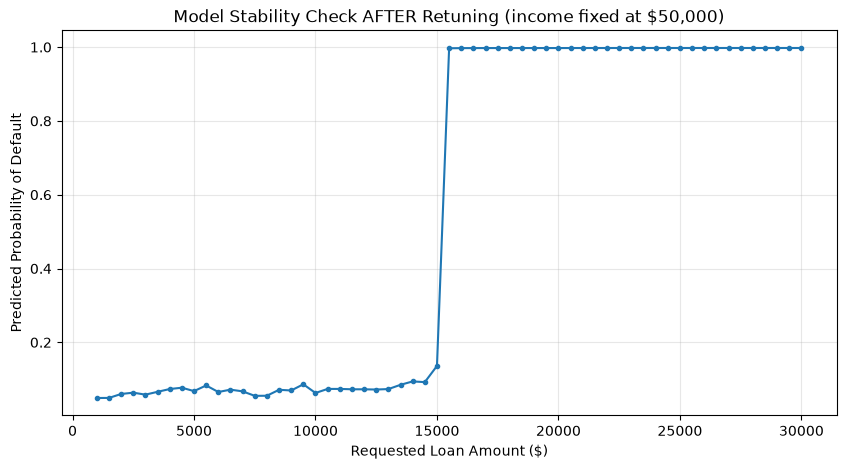

In [21]:
 
# =====================================================================
# CELL J: Re-run the stability check with the retuned model
# =====================================================================
 
import matplotlib.pyplot as plt
 
fixed_income = 50000
loan_amounts = np.arange(1000, 30001, 500)
probs = []
 
numerical_cols_v2 = ['person_age', 'person_income', 'person_emp_length',
                      'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']
cat_cols_v2_check = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
 
for amt in loan_amounts:
    row = {
        'person_age': 30,
        'person_income': fixed_income,
        'person_home_ownership': 'RENT',
        'person_emp_length': 5.0,
        'loan_intent': 'PERSONAL',
        'loan_amnt': amt,
        'loan_percent_income': amt / fixed_income,
        'cb_person_default_on_file': 'N',
        'cb_person_cred_hist_length': 5,
    }
    df_row = pd.DataFrame([row])
 
    scaled = scaler_v2.transform(df_row[numerical_cols_v2])
    df_scaled = pd.DataFrame(scaled, columns=numerical_cols_v2)
 
    df_cat = pd.get_dummies(df_row[cat_cols_v2_check])
 
    df_final = pd.concat([df_scaled, df_cat], axis=1)
    df_final = df_final.reindex(columns=train_columns_v2, fill_value=0)
 
    prob = calibrated_app_model.predict_proba(df_final)[0, 1]
    probs.append(prob)
 
plt.figure(figsize=(10, 5))
plt.plot(loan_amounts, probs, marker='o', markersize=3)
plt.xlabel("Requested Loan Amount ($)")
plt.ylabel("Predicted Probability of Default")
plt.title(f"Model Stability Check AFTER Retuning (income fixed at ${fixed_income:,})")
plt.grid(alpha=0.3)
plt.show()
 


In [ ]:
 
# =====================================================================
# CELL K: If the curve looks smooth now, rebuild grade mapping + re-save
# (same logic as before, just rerun with the new calibrated_app_model)
# =====================================================================
 
import pickle
import os
 
full_probs_v2 = calibrated_app_model.predict_proba(X_v2)[:, 1]
 
df_grade_lookup_v2 = pd.DataFrame({
    'loan_grade': df_original['loan_grade'].values,
    'pred_prob': full_probs_v2,
    'loan_int_rate': df_original['loan_int_rate'].values
})
 
grade_stats_v2 = df_grade_lookup_v2.groupby('loan_grade').agg(
    avg_prob=('pred_prob', 'mean'),
    avg_rate=('loan_int_rate', 'mean')
).sort_values('avg_prob')
 
print(grade_stats_v2)
 
grades_sorted_v2 = grade_stats_v2.index.tolist()
avg_probs_sorted_v2 = grade_stats_v2['avg_prob'].tolist()
 
thresholds_v2 = []
for i in range(len(avg_probs_sorted_v2) - 1):
    midpoint = (avg_probs_sorted_v2[i] + avg_probs_sorted_v2[i + 1]) / 2
    thresholds_v2.append(midpoint)
 
grade_mapping_v2 = {
    'grades_sorted': grades_sorted_v2,
    'thresholds': thresholds_v2,
    'avg_rate_by_grade': grade_stats_v2['avg_rate'].to_dict(),
}
 
os.makedirs('model', exist_ok=True)
os.makedirs('parameter', exist_ok=True)
 
with open('model/model_application_time.pkl', 'wb') as f:
    pickle.dump(calibrated_app_model, f)
 
with open('parameter/grade_mapping.pkl', 'wb') as f:
    pickle.dump(grade_mapping_v2, f)
 
print("Re-saved model_application_time.pkl and grade_mapping.pkl with the retuned model.")

              default_rate  count
lpi_bin                          
(0.0, 0.1]        0.119456   9493
(0.1, 0.15]       0.129718   6067
(0.15, 0.2]       0.178490   4835
(0.2, 0.25]       0.196533   3404
(0.25, 0.28]      0.269062   1364
(0.28, 0.3]       0.239130    828
(0.3, 0.32]       0.683386    638
(0.32, 0.35]      0.687059    850
(0.35, 0.4]       0.694792    960
(0.4, 0.5]        0.738247    787
(0.5, 0.6]        0.786517    178
(0.6, 1.0]        0.770833     48


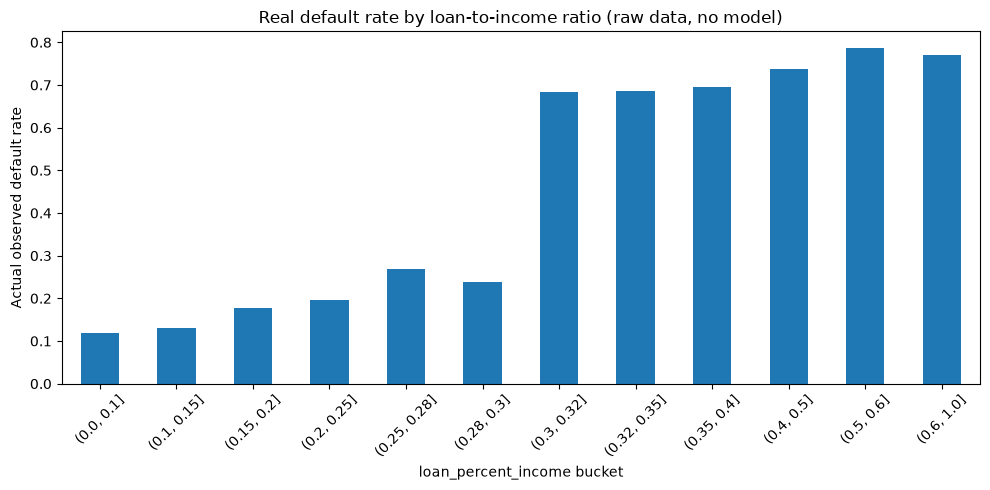

In [22]:
bins = [0, 0.1, 0.15, 0.2, 0.25, 0.28, 0.30, 0.32, 0.35, 0.4, 0.5, 0.6, 1.0]
df_['lpi_bin'] = pd.cut(df_['loan_percent_income'], bins=bins)
 
default_rate_by_bin = df_.groupby('lpi_bin', observed=True)['loan_status'].agg(
    default_rate='mean',
    count='count'
)
 
print(default_rate_by_bin)
 
plt.figure(figsize=(10, 5))
default_rate_by_bin['default_rate'].plot(kind='bar')
plt.xlabel("loan_percent_income bucket")
plt.ylabel("Actual observed default rate")
plt.title("Real default rate by loan-to-income ratio (raw data, no model)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# =====================================================================
# CELL L: Train WITHOUT SMOTETomek -- use CatBoost's native class
# weighting instead, fit on the ORIGINAL imbalanced training data.
# This avoids synthetic oversampling amplifying the real ~30% DTI
# threshold into an unrealistic near-100% separator.
# =====================================================================

from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

catb_app_model_v3 = CatBoostClassifier(
    random_state=42,
    verbose=False,
    auto_class_weights='Balanced',   # native imbalance handling, no synthetic data
    max_depth=5,
    min_data_in_leaf=40,
    l2_leaf_reg=8,
    learning_rate=0.05,
    n_estimators=150
)

# fit on the ORIGINAL (unbalanced) training data -- not X_balanced_v2
catb_app_model_v3.fit(X_train_v2, y_train_v2)

y_proba_v3 = catb_app_model_v3.predict_proba(X_test_v2)[:, 1]
y_pred_v3 = (y_proba_v3 >= 0.5).astype(int)

print(classification_report(y_test_v2, y_pred_v3))
print("ROC-AUC:", roc_auc_score(y_test_v2, y_proba_v3))
print(confusion_matrix(y_test_v2, y_pred_v3))



              precision    recall  f1-score   support

           0       0.91      0.86      0.88      5749
           1       0.58      0.71      0.64      1616

    accuracy                           0.83      7365
   macro avg       0.75      0.78      0.76      7365
weighted avg       0.84      0.83      0.83      7365

ROC-AUC: 0.8683229885869088
[[4939  810]
 [ 476 1140]]


In [24]:

# =====================================================================
# CELL M: Calibrate
# =====================================================================

from sklearn.calibration import CalibratedClassifierCV

calibrated_app_model = CalibratedClassifierCV(catb_app_model_v3, method='sigmoid', cv=5)
calibrated_app_model.fit(X_train_v2, y_train_v2)  # fit on original data too



,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",CatBoostClass...verbose=False)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...0024894860F80>, <sk

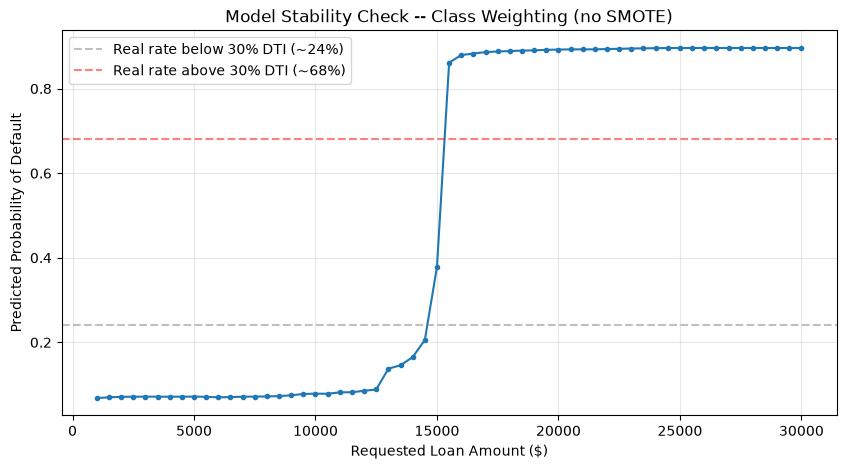

In [25]:

# =====================================================================
# CELL N: Re-run stability check -- compare against the REAL jump
# (24% -> 68%), not a near-100% separator
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fixed_income = 50000
loan_amounts = np.arange(1000, 30001, 500)
probs = []

numerical_cols_v2 = ['person_age', 'person_income', 'person_emp_length',
                      'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']
cat_cols_v2_check = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']

for amt in loan_amounts:
    row = {
        'person_age': 30,
        'person_income': fixed_income,
        'person_home_ownership': 'RENT',
        'person_emp_length': 5.0,
        'loan_intent': 'PERSONAL',
        'loan_amnt': amt,
        'loan_percent_income': amt / fixed_income,
        'cb_person_default_on_file': 'N',
        'cb_person_cred_hist_length': 5,
    }
    df_row = pd.DataFrame([row])

    scaled = scaler_v2.transform(df_row[numerical_cols_v2])
    df_scaled = pd.DataFrame(scaled, columns=numerical_cols_v2)
    df_cat = pd.get_dummies(df_row[cat_cols_v2_check])

    df_final = pd.concat([df_scaled, df_cat], axis=1)
    df_final = df_final.reindex(columns=train_columns_v2, fill_value=0)

    prob = calibrated_app_model.predict_proba(df_final)[0, 1]
    probs.append(prob)

plt.figure(figsize=(10, 5))
plt.plot(loan_amounts, probs, marker='o', markersize=3)
plt.axhline(0.24, color='gray', linestyle='--', alpha=0.5, label='Real rate below 30% DTI (~24%)')
plt.axhline(0.68, color='red', linestyle='--', alpha=0.5, label='Real rate above 30% DTI (~68%)')
plt.xlabel("Requested Loan Amount ($)")
plt.ylabel("Predicted Probability of Default")
plt.title("Model Stability Check -- Class Weighting (no SMOTE)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [29]:

# =====================================================================
# CELL O: If this looks reasonable, rebuild grade mapping + re-save
# =====================================================================

import pickle
import os

full_probs_v3 = calibrated_app_model.predict_proba(X_v2)[:, 1]

df_grade_lookup_v3 = pd.DataFrame({
    'loan_grade': df_['loan_grade'].values,
    'pred_prob': full_probs_v3,
    'loan_int_rate': df_['loan_int_rate'].values
})

grade_stats_v3 = df_grade_lookup_v3.groupby('loan_grade').agg(
    avg_prob=('pred_prob', 'mean'),
    avg_rate=('loan_int_rate', 'mean')
).sort_values('avg_prob')

canonical_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grade_stats_v3 = grade_stats_v3.reindex(canonical_order)
print(grade_stats_v3)

grades_sorted_v3 = grade_stats_v3.index.tolist()
avg_probs_sorted_v3 = grade_stats_v3['avg_prob'].tolist()

thresholds_v3 = []
for i in range(len(avg_probs_sorted_v3) - 1):
    midpoint = (avg_probs_sorted_v3[i] + avg_probs_sorted_v3[i + 1]) / 2
    thresholds_v3.append(midpoint)

grade_mapping_v3 = {
    'grades_sorted': grades_sorted_v3,
    'thresholds': thresholds_v3,
    'avg_rate_by_grade': grade_stats_v3['avg_rate'].to_dict(),
    'avg_prob_by_grade': grade_stats_v3['avg_prob'].to_dict(),   # add this
}

os.makedirs('model', exist_ok=True)
os.makedirs('parameter', exist_ok=True)

with open('model/model_application_time.pkl', 'wb') as f:
    pickle.dump(calibrated_app_model, f)

with open('parameter/grade_mapping.pkl', 'wb') as f:
    pickle.dump(grade_mapping_v3, f)

print("Re-saved with class-weighted (no SMOTE) model.")

            avg_prob   avg_rate
loan_grade                     
A           0.139388   7.327732
B           0.182473  10.995542
C           0.306872  13.463649
D           0.355144  15.361250
E           0.355031  17.009455
F           0.369294  18.609159
G           0.415016  20.251525
Re-saved with class-weighted (no SMOTE) model.
